# Trader Sentiment Analysis 📈

## OBJECTIVE :
 - Analyze how market sentiment (Fear/Greed) affects the trader behaviour and performance on HyperLiquid.
 - Uncover patterns that can help in making smarter trading decisions.


### PART A - DATA PREPARATION

- Load the datasets
  -  Number of rows and columns
  -  Missing values and duplicates
- Convert timestamps and align the two datasets
- Create key metrics
  - Daily PnL per trader (or per account)
  - Win rate
  - Average trade size
  - Leverage distribution
  - Number of trades per day
  - Long/short ratio


In [150]:
# Step 1 : Import Libraries 

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("Libraries imported successfully")



Libraries imported successfully


In [151]:
# Step 2 : Load datasets

fg_df = pd.read_csv("fear_greed_index.csv")
trade_df = pd.read_csv("historical_data.csv")

print("FEAR AND GREED INDEX DATASET")
print(f"Shape:{fg_df.shape[0]} rows and {fg_df.shape[1]} columns")
print(f"\nColumns: {list(fg_df.columns)}")
print(f"\nData Types:\n{fg_df.dtypes}")
print(f"\nFirst 5 rows:")
fg_df.head()


FEAR AND GREED INDEX DATASET
Shape:2644 rows and 4 columns

Columns: ['timestamp', 'value', 'classification', 'date']

Data Types:
timestamp          int64
value              int64
classification    object
date              object
dtype: object

First 5 rows:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [152]:
print("HISTORICAL DATA DATASET")
print(f"Shape:{trade_df.shape[0]} rows and {trade_df.shape[1]} columns")
print(f"\nColumns: {list(trade_df.columns)}")
print(f"\nData Types:\n{trade_df.dtypes}")
print(f"\nFirst 5 rows:")
trade_df.head()


HISTORICAL DATA DATASET
Shape:211224 rows and 16 columns

Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Data Types:
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

First 5 rows:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.8700,7872.1600,BUY,02-12-2024 22:50,0.0000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.3454,895000000000000.0000,1730000000000.0000
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.0000,127.6800,BUY,02-12-2024 22:50,986.5246,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0056,443000000000000.0000,1730000000000.0000
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.0900,1150.6300,BUY,02-12-2024 22:50,1002.5190,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0504,660000000000000.0000,1730000000000.0000
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.9800,1142.0400,BUY,02-12-2024 22:50,1146.5586,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0500,1080000000000000.0000,1730000000000.0000
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.7300,69.7500,BUY,02-12-2024 22:50,1289.4885,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0031,1050000000000000.0000,1730000000000.0000


In [153]:
# Step 3 : Data Quality Check - Missing Values and Duplicates

print("FEAR AND GREED INDEX DATASET QUALITY")

# Missing Values
fg_missing = fg_df.isnull().sum()
fg_missing_percent = ((fg_missing / len(fg_df)) * 100).round(2)
fg_quality = pd.DataFrame({'Missing Values': fg_missing, 'Percentage': fg_missing_percent})
print("\nMissing Values:")
print(fg_quality)

# Duplicates 
fg_duplicates = fg_df.duplicated().sum()
fg_date_duplicates = fg_df.duplicated(subset=['date']).sum()    
print (f"\nDuplicate Rows: {fg_duplicates}")
print(f"Duplicate Dates: {fg_date_duplicates}")




FEAR AND GREED INDEX DATASET QUALITY

Missing Values:
                Missing Values  Percentage
timestamp                    0      0.0000
value                        0      0.0000
classification               0      0.0000
date                         0      0.0000

Duplicate Rows: 0
Duplicate Dates: 0


In [154]:
print("HISTORICAL DATASET QUALITY")

# Missing Values
trade_missing = trade_df.isnull().sum()
trade_missing_percent = ((trade_missing / len(trade_df)) * 100).round(2)
trade_quality = pd.DataFrame({'Missing Values': trade_missing, 'Percentage': trade_missing_percent})
print("\nMissing Values:")
print(trade_quality)

# Duplicates
trade_dupes = trade_df.duplicated().sum()
print(f"\nDuplicate Rows: {trade_dupes}")

# Remove duplicates if any
if trade_dupes > 0:
    trade_df = trade_df.drop_duplicates().reset_index(drop=True)
    print(f" Removed {trade_dupes} duplicates. New shape: {trade_df.shape}")
if fg_duplicates > 0:
    fg_df = fg_df.drop_duplicates().reset_index(drop=True)
    print(f" Removed {fg_duplicates} FG duplicates. New shape: {fg_df.shape}")

HISTORICAL DATASET QUALITY

Missing Values:
                  Missing Values  Percentage
Account                        0      0.0000
Coin                           0      0.0000
Execution Price                0      0.0000
Size Tokens                    0      0.0000
Size USD                       0      0.0000
Side                           0      0.0000
Timestamp IST                  0      0.0000
Start Position                 0      0.0000
Direction                      0      0.0000
Closed PnL                     0      0.0000
Transaction Hash               0      0.0000
Order ID                       0      0.0000
Crossed                        0      0.0000
Fee                            0      0.0000
Trade ID                       0      0.0000
Timestamp                      0      0.0000

Duplicate Rows: 0


In [155]:
# Step 4 : Convert Timestamps and align datasets by Date

# Fear and Greed dataset

fg_df['date'] = pd.to_datetime(fg_df['date'])
fg_df['value'] = fg_df['value'].astype(int)

print("Fear and Greed Index date range:")
print(f"From: {fg_df['date'].min().date()} To: {fg_df['date'].max().date()}")
print(f"Total Days: {fg_df['date'].nunique()}")
print(f"Classifications:{fg_df['classification'].value_counts().to_dict()}")


Fear and Greed Index date range:
From: 2018-02-01 To: 2025-05-02
Total Days: 2644
Classifications:{'Fear': 781, 'Greed': 633, 'Extreme Fear': 508, 'Neutral': 396, 'Extreme Greed': 326}


In [156]:
# Historical dataset

print("Trading data columns:", list(trade_df.columns))
print("\nSample values (first 3 rows):")
print(trade_df.head(3).to_string())

Trading data columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Sample values (first 3 rows):
                                      Account  Coin  Execution Price  Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  Closed PnL                                                    Transaction Hash     Order ID  Crossed    Fee             Trade ID          Timestamp
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769     986.8700 7872.1600  BUY  02-12-2024 22:50          0.0000       Buy      0.0000  0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49  52017706630     True 0.3454 895000000000000.0000 1730000000000.0000
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800      16.0000  127.6800  BUY  02-12-2024 22:50        986.5246       Buy      0.0000  0x

In [157]:

# Convert trading data timestamp to datetime
# First, let's check what timestamp columns we have
timestamp_cols = [c for c in trade_df.columns if any(k in c.lower() for k in ['time', 'date', 'ts'])]
print(f"Detected timestamp columns: {timestamp_cols}")

# The 'Timestamp IST' column has format: "DD-MM-YYYY HH:MM"
# The 'Timestamp' column is epoch (numeric)

# Option 1: Use the 'Timestamp IST' column with correct format
if 'Timestamp IST' in trade_df.columns:
    trade_df['date'] = pd.to_datetime(
        trade_df['Timestamp IST'], 
        format='%d-%m-%Y %H:%M',
        errors='coerce'
    ).dt.normalize()
    print("Converted 'Timestamp IST' to date")

# Option 2: Use the numeric 'Timestamp' column as fallback
elif 'Timestamp' in trade_df.columns:
    # Check if it's epoch milliseconds or seconds
    sample_val = trade_df['Timestamp'].iloc[0]
    if sample_val > 1e12:
        trade_df['date'] = pd.to_datetime(trade_df['Timestamp'], unit='ms').dt.normalize()
    else:
        trade_df['date'] = pd.to_datetime(trade_df['Timestamp'], unit='s').dt.normalize()
    print("Converted 'Timestamp' (epoch) to date")

# Check for any conversion failures
null_dates = trade_df['date'].isna().sum()
if null_dates > 0:
    print(f"Warning: {null_dates} rows failed to convert. Dropping them.")
    trade_df = trade_df.dropna(subset=['date']).reset_index(drop=True)

print(f"\nTrading Data — Date Range:")
print(f"  From: {trade_df['date'].min().date()}  To: {trade_df['date'].max().date()}")
print(f"  Total unique dates: {trade_df['date'].nunique()}")
print(f"  Total rows: {len(trade_df):,}")

Detected timestamp columns: ['Timestamp IST', 'Timestamp']
Converted 'Timestamp IST' to date

Trading Data — Date Range:
  From: 2023-05-01  To: 2025-05-01
  Total unique dates: 480
  Total rows: 211,224


In [158]:
# Identify overlapping date range
date_min = max(fg_df['date'].min(), trade_df['date'].min())
date_max = min(fg_df['date'].max(), trade_df['date'].max())

print(f" Overlapping Date Range: {date_min.date()} → {date_max.date()}")
print(f"   Duration: {(date_max - date_min).days} days")

# Filter both datasets to the overlapping range
fg_aligned = fg_df[(fg_df['date'] >= date_min) & (fg_df['date'] <= date_max)].copy()
trade_aligned = trade_df[(trade_df['date'] >= date_min) & (trade_df['date'] <= date_max)].copy()

print(f"\n   Fear & Greed rows (aligned): {len(fg_aligned)}")
print(f"   Trading data rows (aligned):  {len(trade_aligned)}")

 Overlapping Date Range: 2023-05-01 → 2025-05-01
   Duration: 731 days

   Fear & Greed rows (aligned): 731
   Trading data rows (aligned):  211224


In [159]:
# Step 5 : Create Key Metrics
print ("Available columns in trading data:")
for i,col in enumerate(trade_aligned.columns):
    print(f"  {i}: {col} — dtype: {trade_aligned[col].dtype} — sample: {trade_aligned[col].iloc[0]}")

Available columns in trading data:
  0: Account — dtype: object — sample: 0xae5eacaf9c6b9111fd53034a602c192a04e082ed
  1: Coin — dtype: object — sample: @107
  2: Execution Price — dtype: float64 — sample: 7.9769
  3: Size Tokens — dtype: float64 — sample: 986.87
  4: Size USD — dtype: float64 — sample: 7872.16
  5: Side — dtype: object — sample: BUY
  6: Timestamp IST — dtype: object — sample: 02-12-2024 22:50
  7: Start Position — dtype: float64 — sample: 0.0
  8: Direction — dtype: object — sample: Buy
  9: Closed PnL — dtype: float64 — sample: 0.0
  10: Transaction Hash — dtype: object — sample: 0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49
  11: Order ID — dtype: int64 — sample: 52017706630
  12: Crossed — dtype: bool — sample: True
  13: Fee — dtype: float64 — sample: 0.34540448
  14: Trade ID — dtype: float64 — sample: 895000000000000.0
  15: Timestamp — dtype: float64 — sample: 1730000000000.0
  16: date — dtype: datetime64[ns] — sample: 2024-12-02 00:00:00

In [208]:
# =============================================================
# Step 5: Configure Column Mappings
# =============================================================
# Map actual CSV column names to standardized variable names

ACCOUNT_COL    = 'Account'           # Trader/account identifier
PNL_COL        = 'Closed PnL'       # Profit & Loss
SIZE_TOKENS_COL = 'Size Tokens'     # Trade size in tokens
SIZE_USD_COL   = 'Size USD'         # Trade size in USD (pre-calculated)
SIZE_COL       = 'Size USD'         # Alias used in some cells
PRICE_COL      = 'Execution Price'  # Execution price
SIDE_COL       = 'Side'             # BUY / SELL
COIN_COL       = 'Coin'             # Asset / symbol
DIRECTION_COL  = 'Direction'        # Open / Close direction
LEVERAGE_COL   = None               # Not available in this dataset

# Verify all required columns exist
required = {
    'Account':   ACCOUNT_COL,
    'PnL':       PNL_COL,
    'Size USD':  SIZE_USD_COL,
    'Price':     PRICE_COL,
    'Side':      SIDE_COL,
    'Coin':      COIN_COL,
}

print("Column mappings configured:\n")
for label, col in required.items():
    exists = "✓" if col in trade_aligned.columns else "✗ NOT FOUND"
    print(f"   {label:15s} → '{col}'  {exists}")

print(f"\n   {'Leverage':15s} → Not available in this dataset")

Column mappings configured:

   Account         → 'Account'  ✓
   PnL             → 'Closed PnL'  ✓
   Size USD        → 'Size USD'  ✓
   Price           → 'Execution Price'  ✓
   Side            → 'Side'  ✓
   Coin            → 'Coin'  ✓

   Leverage        → Not available in this dataset


In [209]:
# Cell - Replace the data preparation cell with this fixed version:

# =============================================================
# Prepare Trading Data - Create Derived Columns
# =============================================================

# Convert to numeric types
numeric_cols = [PNL_COL, SIZE_TOKENS_COL, SIZE_USD_COL, PRICE_COL]
for col in numeric_cols:
    if col in trade_aligned.columns:
        trade_aligned[col] = pd.to_numeric(trade_aligned[col], errors='coerce')
        print(f"✓ Converted '{col}' to numeric")

# Create notional_usd column from pre-calculated Size USD
if SIZE_USD_COL in trade_aligned.columns:
    trade_aligned['notional_usd'] = trade_aligned[SIZE_USD_COL].abs()
    print(f"\n Created 'notional_usd' from '{SIZE_USD_COL}'")
elif SIZE_TOKENS_COL in trade_aligned.columns and PRICE_COL in trade_aligned.columns:
    trade_aligned['notional_usd'] = (trade_aligned[SIZE_TOKENS_COL] * trade_aligned[PRICE_COL]).abs()
    print(f"\n Created 'notional_usd' = |{SIZE_TOKENS_COL} × {PRICE_COL}|")
else:
    print("\n Cannot create notional_usd - required columns missing")

# Flag winning trades (PnL > 0)
if PNL_COL in trade_aligned.columns:
    trade_aligned['is_win'] = (trade_aligned[PNL_COL] > 0).astype(int)
    win_count = trade_aligned['is_win'].sum()
    total_count = len(trade_aligned)
    print(f" Created 'is_win' flag: {win_count:,} wins / {total_count:,} total ({win_count/total_count*100:.1f}%)")

# Standardize side to 'Long' / 'Short'
if SIDE_COL in trade_aligned.columns:
    side_vals = trade_aligned[SIDE_COL].unique()
    print(f"\n   Unique side values: {side_vals}")
    
    # Map BUY/SELL to Long/Short
    side_map = {
        'BUY': 'Long', 
        'SELL': 'Short',
        'Buy': 'Long', 
        'Sell': 'Short',
        'buy': 'Long', 
        'sell': 'Short',
    }
    trade_aligned['side_label'] = trade_aligned[SIDE_COL].map(side_map)
    
    # Keep original if not mapped
    unmapped = trade_aligned['side_label'].isna().sum()
    if unmapped > 0:
        print(f"    {unmapped} rows with unmapped side values — keeping original")
        trade_aligned['side_label'] = trade_aligned['side_label'].fillna(trade_aligned[SIDE_COL])
    
    print(f"\n   Side distribution:")
    print(trade_aligned['side_label'].value_counts().to_string())

# Drop rows with critical missing values
null_before = len(trade_aligned)
critical_cols = ['notional_usd', PNL_COL, 'is_win']
existing_critical = [c for c in critical_cols if c in trade_aligned.columns]
trade_aligned = trade_aligned.dropna(subset=existing_critical).reset_index(drop=True)
null_after = len(trade_aligned)

if null_before != null_after:
    print(f"\n Dropped {null_before - null_after:,} rows with null critical values")

print(f"\nTrading data ready — {len(trade_aligned):,} rows")
print(f"   Columns: {list(trade_aligned.columns)}")

✓ Converted 'Closed PnL' to numeric
✓ Converted 'Size Tokens' to numeric
✓ Converted 'Size USD' to numeric
✓ Converted 'Execution Price' to numeric

 Created 'notional_usd' from 'Size USD'
 Created 'is_win' flag: 86,869 wins / 211,224 total (41.1%)

   Unique side values: ['BUY' 'SELL']

   Side distribution:
side_label
Short    108528
Long     102696

Trading data ready — 211,224 rows
   Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'notional_usd', 'is_win', 'side_label']


In [210]:
# Cell - Daily PnL per Trader (should now work):

# =============================================================
# METRIC 1: Daily PnL per Trader
# =============================================================

daily_pnl_trader = (
    trade_aligned
    .groupby(['date', ACCOUNT_COL])[PNL_COL]
    .sum()
    .reset_index()
    .rename(columns={PNL_COL: 'daily_pnl'})
)

print(f" Daily PnL per Trader")
print(f"   Shape: {daily_pnl_trader.shape}")
print(f"   Unique traders: {daily_pnl_trader[ACCOUNT_COL].nunique()}")
print(f"   Date range: {daily_pnl_trader['date'].min().date()} → {daily_pnl_trader['date'].max().date()}")
print(f"\n   PnL Statistics:")
print(daily_pnl_trader['daily_pnl'].describe().to_string())
print("\n   Sample rows:")
daily_pnl_trader.head(10)

 Daily PnL per Trader
   Shape: (2341, 3)
   Unique traders: 32
   Date range: 2023-05-01 → 2025-05-01

   PnL Statistics:
count      2341.0000
mean       4398.5301
std       28415.9390
min     -358963.1400
25%           0.0000
50%         207.9835
75%        1842.8399
max      533974.6629

   Sample rows:


,date,Account,daily_pnl
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.0000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.0000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.4347
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.6320
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.0000
5,2023-12-17,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,304.9828
6,2023-12-18,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.0000
7,2023-12-19,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1000.5386
8,2023-12-20,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,162.7323
9,2023-12-21,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,537.2114


In [211]:
# Cell - Daily Aggregated Metrics (should now work):

# =============================================================
# METRIC 2-6: Daily Aggregated Metrics
# =============================================================

# Helper: count longs and shorts per day
if 'side_label' in trade_aligned.columns:
    long_count = trade_aligned[trade_aligned['side_label'] == 'Long'].groupby('date').size()
    short_count = trade_aligned[trade_aligned['side_label'] == 'Short'].groupby('date').size()
else:
    long_count = pd.Series(dtype='int64')
    short_count = pd.Series(dtype='int64')

# Build daily metrics
daily_metrics = trade_aligned.groupby('date').agg(
    total_pnl       = (PNL_COL, 'sum'),
    mean_pnl        = (PNL_COL, 'mean'),
    median_pnl      = (PNL_COL, 'median'),
    num_trades      = (PNL_COL, 'count'),
    num_winners     = ('is_win', 'sum'),
    avg_trade_size  = ('notional_usd', 'mean'),
    median_trade_size = ('notional_usd', 'median'),
    total_volume    = ('notional_usd', 'sum'),
    unique_traders  = (ACCOUNT_COL, 'nunique'),
).reset_index()

# Win rate
daily_metrics['win_rate'] = (daily_metrics['num_winners'] / daily_metrics['num_trades'] * 100).round(2)

# Long/Short counts and ratio
daily_metrics['long_count'] = daily_metrics['date'].map(long_count).fillna(0).astype(int)
daily_metrics['short_count'] = daily_metrics['date'].map(short_count).fillna(0).astype(int)
daily_metrics['long_short_ratio'] = (
    daily_metrics['long_count'] / daily_metrics['short_count'].replace(0, np.nan)
).round(4)

print(f" Daily Aggregated Metrics")
print(f"   Shape: {daily_metrics.shape}")
print(f"   Date range: {daily_metrics['date'].min().date()} → {daily_metrics['date'].max().date()}")
print(f"\n   Columns: {list(daily_metrics.columns)}")
print("\n   Sample rows:")
daily_metrics.head(10)

 Daily Aggregated Metrics
   Shape: (480, 14)
   Date range: 2023-05-01 → 2025-05-01

   Columns: ['date', 'total_pnl', 'mean_pnl', 'median_pnl', 'num_trades', 'num_winners', 'avg_trade_size', 'median_trade_size', 'total_volume', 'unique_traders', 'win_rate', 'long_count', 'short_count', 'long_short_ratio']

   Sample rows:


,date,total_pnl,mean_pnl,median_pnl,num_trades,num_winners,avg_trade_size,median_trade_size,total_volume,unique_traders,win_rate,long_count,short_count,long_short_ratio
0,2023-05-01,0.0000,0.0000,0.0000,3,0,159.0000,156.3900,477.0000,1,0.0000,3,0,NaN
1,2023-12-05,0.0000,0.0000,0.0000,9,0,5556.2033,1935.9500,50005.8300,1,0.0000,7,2,3.5000
2,2023-12-14,-205.4347,-18.6759,0.0000,11,4,10291.2136,8677.2800,113203.3500,1,36.3600,5,6,0.8333
3,2023-12-15,-24.6320,-12.3160,-12.3160,2,0,5304.9750,5304.9750,10609.9500,1,0.0000,2,0,NaN
4,2023-12-16,0.0000,0.0000,0.0000,3,0,5116.2567,4680.1400,15348.7700,1,0.0000,3,0,NaN
5,2023-12-17,304.9828,21.7845,0.0268,14,7,8305.5729,5368.0200,116278.0200,1,50.0000,3,11,0.2727
6,2023-12-18,0.0000,0.0000,0.0000,2,0,15582.0900,15582.0900,31164.1800,1,0.0000,2,0,NaN
7,2023-12-19,1000.5386,66.7026,4.5026,15,10,6106.8273,4728.6700,91602.4100,1,66.6700,5,10,0.5000
8,2023-12-20,162.7323,9.0407,0.0000,18,8,7868.7106,7686.9350,141636.7900,1,44.4400,10,8,1.2500
9,2023-12-21,537.2114,10.9635,0.0326,49,26,2555.7953,2182.4500,125233.9700,1,53.0600,22,27,0.8148


#### 5.3 — Summary Statistics of Daily Metrics

In [212]:
# Cell 23 - code
# =============================================================
# Summary Statistics
# =============================================================
summary_cols = ['total_pnl', 'num_trades', 'win_rate', 'avg_trade_size', 
                'total_volume', 'unique_traders', 'long_short_ratio']

# Add leverage if present
if 'avg_leverage' in daily_metrics.columns:
    summary_cols.append('avg_leverage')

print(" Summary Statistics — Daily Metrics\n")
print(daily_metrics[summary_cols].describe().round(2).to_string())

 Summary Statistics — Daily Metrics

         total_pnl  num_trades  win_rate  avg_trade_size  total_volume  unique_traders  long_short_ratio
count     480.0000    480.0000  480.0000        480.0000      480.0000        480.0000          444.0000
mean    21452.0000    440.0500   36.6500       6141.7500  2481640.5100          4.8800            2.2300
std     71861.4600    809.7500   26.3700       5575.0200  6284835.0700          4.9100            6.9400
min   -419020.2300      1.0000    0.0000          0.1100        0.1100          1.0000            0.0000
25%         7.2500     18.0000   18.2400       2201.1900    97510.2100          1.0000            0.4600
50%      1118.9600     67.5000   35.2800       4337.9800   327208.5800          2.0000            0.8400
75%     10669.3200    520.5000   50.3200       8195.7500  1648099.7000          8.2500            1.5100
max    616413.0300   6246.0000  100.0000      34988.5800 55914617.4900         20.0000           87.0000


In [165]:
### Step 6: Merge Trading Metrics with Fear & Greed Index

In [213]:
# Cell 25 - code
# =============================================================
# MERGE: Daily metrics + Fear & Greed Index
# =============================================================
fg_clean = fg_aligned[['date', 'value', 'classification']].rename(
    columns={'value': 'fg_value', 'classification': 'fg_class'}
)

merged_df = daily_metrics.merge(fg_clean, on='date', how='inner')

print(f" Merged Dataset")
print(f"   Shape: {merged_df.shape}")
print(f"   Date range: {merged_df['date'].min().date()} → {merged_df['date'].max().date()}")
print(f"   Total days: {len(merged_df)}")
print(f"\n   Sentiment Distribution:")
print(merged_df['fg_class'].value_counts().to_string())

merged_df.head(10)

 Merged Dataset
   Shape: (479, 16)
   Date range: 2023-05-01 → 2025-05-01
   Total days: 479

   Sentiment Distribution:
fg_class
Greed            193
Extreme Greed    114
Fear              91
Neutral           67
Extreme Fear      14


,date,total_pnl,mean_pnl,median_pnl,num_trades,num_winners,avg_trade_size,median_trade_size,total_volume,unique_traders,win_rate,long_count,short_count,long_short_ratio,fg_value,fg_class
0,2023-05-01,0.0000,0.0000,0.0000,3,0,159.0000,156.3900,477.0000,1,0.0000,3,0,NaN,63,Greed
1,2023-12-05,0.0000,0.0000,0.0000,9,0,5556.2033,1935.9500,50005.8300,1,0.0000,7,2,3.5000,75,Extreme Greed
2,2023-12-14,-205.4347,-18.6759,0.0000,11,4,10291.2136,8677.2800,113203.3500,1,36.3600,5,6,0.8333,72,Greed
3,2023-12-15,-24.6320,-12.3160,-12.3160,2,0,5304.9750,5304.9750,10609.9500,1,0.0000,2,0,NaN,70,Greed
4,2023-12-16,0.0000,0.0000,0.0000,3,0,5116.2567,4680.1400,15348.7700,1,0.0000,3,0,NaN,67,Greed
5,2023-12-17,304.9828,21.7845,0.0268,14,7,8305.5729,5368.0200,116278.0200,1,50.0000,3,11,0.2727,73,Greed
6,2023-12-18,0.0000,0.0000,0.0000,2,0,15582.0900,15582.0900,31164.1800,1,0.0000,2,0,NaN,65,Greed
7,2023-12-19,1000.5386,66.7026,4.5026,15,10,6106.8273,4728.6700,91602.4100,1,66.6700,5,10,0.5000,73,Greed
8,2023-12-20,162.7323,9.0407,0.0000,18,8,7868.7106,7686.9350,141636.7900,1,44.4400,10,8,1.2500,74,Greed
9,2023-12-21,537.2114,10.9635,0.0326,49,26,2555.7953,2182.4500,125233.9700,1,53.0600,22,27,0.8148,70,Greed


In [167]:
### Step 7: Leverage Distribution Overview

In [214]:
# Cell 27 - code
# =============================================================
# Leverage Distribution (from raw trade data)
# =============================================================
if LEVERAGE_COL and LEVERAGE_COL in trade_aligned.columns:
    print(" Leverage Distribution\n")
    print(trade_aligned[LEVERAGE_COL].describe().to_string())

    # Bin leverage into categories
    bins = [0, 2, 5, 10, 20, 50, 100, float('inf')]
    labels = ['1-2x', '2-5x', '5-10x', '10-20x', '20-50x', '50-100x', '100x+']
    trade_aligned['leverage_bin'] = pd.cut(
        trade_aligned[LEVERAGE_COL], bins=bins, labels=labels, right=True
    )
    
    lev_dist = trade_aligned['leverage_bin'].value_counts().sort_index()
    lev_pct = (lev_dist / len(trade_aligned) * 100).round(2)
    lev_summary = pd.DataFrame({'Count': lev_dist, 'Percentage': lev_pct})
    
    print(f"\n   Leverage Buckets:")
    print(lev_summary.to_string())
else:
    print(" No leverage column available in the dataset")
    print("   Skipping leverage distribution analysis")

 No leverage column available in the dataset
   Skipping leverage distribution analysis


### Step 8: Data Preparation Summary

In [215]:
# Cell 29 - code
# =============================================================
# FINAL SUMMARY
# =============================================================
print("=" * 60)
print(" DATA PREPARATION COMPLETE")
print("=" * 60)

print(f"""
 Datasets Loaded:
   • Fear & Greed Index : {len(fg_df)} rows ({fg_df['date'].min().date()} → {fg_df['date'].max().date()})
   • Historical Trades  : {len(trade_df)} rows ({trade_df['date'].min().date()} → {trade_df['date'].max().date()})

 Aligned & Merged:
   • Overlapping period  : {merged_df['date'].min().date()} → {merged_df['date'].max().date()}
   • Days with data      : {len(merged_df)}
   • Unique traders      : {trade_aligned[ACCOUNT_COL].nunique()}
   • Total trades        : {len(trade_aligned):,}

 Key Metrics Created:
   ✓ Daily PnL per trader       (daily_pnl_trader)
   ✓ Win rate                   (merged_df['win_rate'])
   ✓ Average trade size         (merged_df['avg_trade_size'])
   ✓ Leverage distribution      ({'✓ Available' if LEVERAGE_COL and LEVERAGE_COL in trade_aligned.columns else '✗ Not in dataset'})
   ✓ Number of trades per day   (merged_df['num_trades'])
   ✓ Long/Short ratio           (merged_df['long_short_ratio'])

 Ready for Analysis:
   • merged_df         — daily metrics + sentiment ({merged_df.shape})
   • daily_pnl_trader  — trader-level daily PnL  ({daily_pnl_trader.shape})
   • trade_aligned     — cleaned trade-level data ({trade_aligned.shape})
""")

 DATA PREPARATION COMPLETE

 Datasets Loaded:
   • Fear & Greed Index : 2644 rows (2018-02-01 → 2025-05-02)
   • Historical Trades  : 211224 rows (2023-05-01 → 2025-05-01)

 Aligned & Merged:
   • Overlapping period  : 2023-05-01 → 2025-05-01
   • Days with data      : 479
   • Unique traders      : 32
   • Total trades        : 211,224

 Key Metrics Created:
   ✓ Daily PnL per trader       (daily_pnl_trader)
   ✓ Win rate                   (merged_df['win_rate'])
   ✓ Average trade size         (merged_df['avg_trade_size'])
   ✓ Leverage distribution      (✗ Not in dataset)
   ✓ Number of trades per day   (merged_df['num_trades'])
   ✓ Long/Short ratio           (merged_df['long_short_ratio'])

 Ready for Analysis:
   • merged_df         — daily metrics + sentiment ((479, 16))
   • daily_pnl_trader  — trader-level daily PnL  ((2341, 3))
   • trade_aligned     — cleaned trade-level data ((211224, 20))



### PART B - ANALYSIS

- Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
- Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?
- Identify 2–3 trader segments, e.g.:
  - High leverage vs low leverage traders
  - Frequent vs infrequent traders
  - Consistent winners vs inconsistent traders
- Provide at least 3 insights backed by charts/tables.


In [216]:
# =============================================================
# PART B — ANALYSIS
# =============================================================
# Import visualization libraries

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print(" Visualization libraries loaded")

 Visualization libraries loaded


In [217]:
# =============================================================
# B.1 — SENTIMENT REGIME CLASSIFICATION
# =============================================================
# Create a simplified sentiment bucket for cleaner comparisons

def classify_sentiment(value):
    if value <= 25:
        return 'Extreme Fear'
    elif value <= 45:
        return 'Fear'
    elif value <= 55:
        return 'Neutral'
    elif value <= 75:
        return 'Greed'
    else:
        return 'Extreme Greed'

merged_df['sentiment'] = merged_df['fg_value'].apply(classify_sentiment)

# Define order for consistent plotting
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sentiment_colors = {
    'Extreme Fear': '#d32f2f',
    'Fear': '#ff7043',
    'Neutral': '#ffd54f',
    'Greed': '#66bb6a',
    'Extreme Greed': '#2e7d32'
}

print(" Sentiment Distribution (merged dataset):\n")
dist = merged_df['sentiment'].value_counts().reindex(sentiment_order)
for s in sentiment_order:
    count = dist.get(s, 0)
    pct = count / len(merged_df) * 100
    print(f"   {s:16s} : {count:4d} days  ({pct:5.1f}%)")

print(f"\n   Total days: {len(merged_df)}")

 Sentiment Distribution (merged dataset):

   Extreme Fear     :   22 days  (  4.6%)
   Fear             :   87 days  ( 18.2%)
   Neutral          :   69 days  ( 14.4%)
   Greed            :  208 days  ( 43.4%)
   Extreme Greed    :   93 days  ( 19.4%)

   Total days: 479


---
## B.1 — Does Performance Differ Between Fear vs Greed Days?

We compare PnL, win rate, and a drawdown proxy across sentiment regimes.

---

In [218]:
# =============================================================
# B.1.1 — Performance Summary Table by Sentiment
# =============================================================

perf_by_sentiment = merged_df.groupby('sentiment').agg(
    days              = ('date', 'count'),
    avg_daily_pnl     = ('total_pnl', 'mean'),
    median_daily_pnl  = ('total_pnl', 'median'),
    total_pnl         = ('total_pnl', 'sum'),
    avg_win_rate      = ('win_rate', 'mean'),
    avg_num_trades    = ('num_trades', 'mean'),
    avg_trade_size    = ('avg_trade_size', 'mean'),
    avg_volume        = ('total_volume', 'mean'),
    avg_ls_ratio      = ('long_short_ratio', 'mean'),
).reindex(sentiment_order)

print(" Performance Summary by Sentiment Regime\n")
print(perf_by_sentiment.round(2).to_string())

 Performance Summary by Sentiment Regime

               days  avg_daily_pnl  median_daily_pnl    total_pnl  avg_win_rate  avg_num_trades  avg_trade_size   avg_volume  avg_ls_ratio
sentiment                                                                                                                                 
Extreme Fear     22     49495.9300         6754.8600 1088910.3900       34.3400       1425.6400       4528.3000 7316696.3400        2.5900
Fear             87     36519.1500         1876.8100 3177166.4700       32.6600        635.9500       6535.0400 5256663.2000        2.8600
Neutral          69     18058.6100         1118.3900 1246044.0400       33.2300        526.1200       7214.4000 2388329.1800        2.3900
Greed           208     11149.5900          768.2200 2319114.5800       34.6900        268.2800       6496.4700 1471846.5800        1.9300
Extreme Greed    93     26056.4700         3494.4000 2423251.4800       47.1500        348.6100       4473.4500 1095300.5900

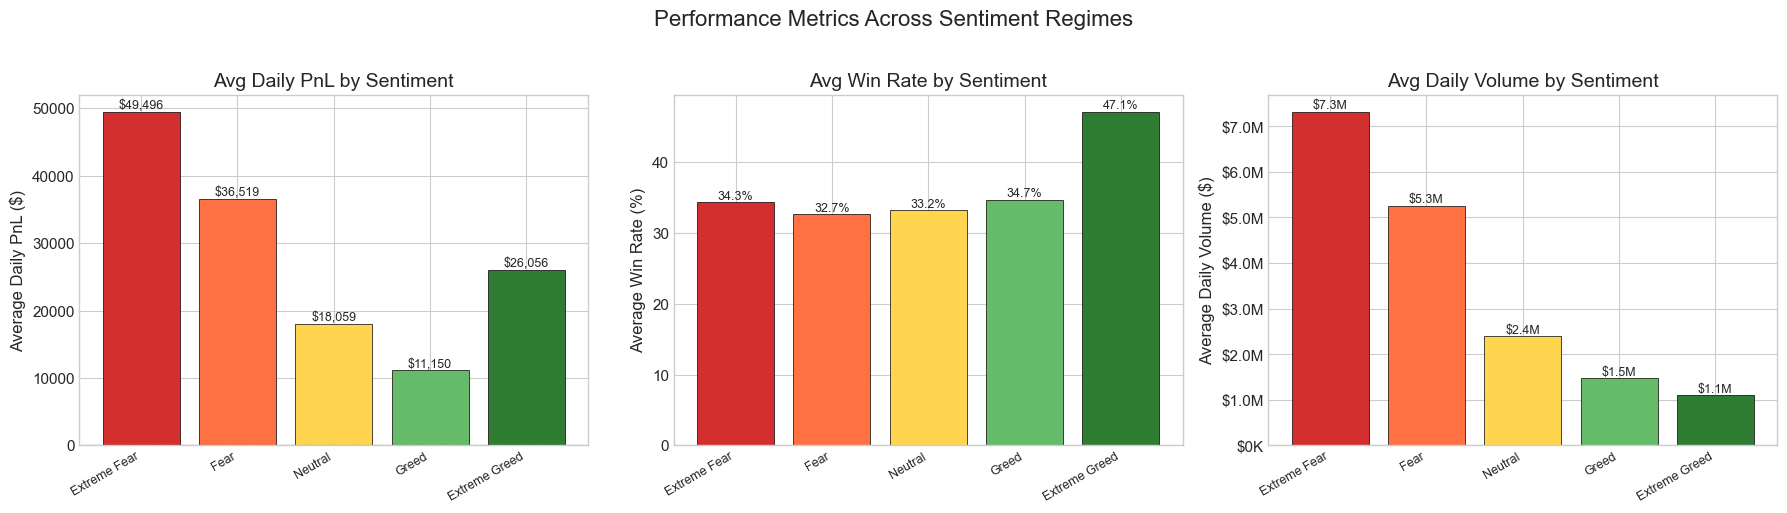

In [173]:
# =============================================================
# B.1.2 — Chart: Average Daily PnL by Sentiment
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Average Daily PnL ---
ax = axes[0]
data = perf_by_sentiment['avg_daily_pnl']
colors = [sentiment_colors[s] for s in data.index]
bars = ax.bar(range(len(data)), data.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(data)))
ax.set_xticklabels(data.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Average Daily PnL ($)')
ax.set_title('Avg Daily PnL by Sentiment')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'${val:,.0f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)

# --- Panel 2: Average Win Rate ---
ax = axes[1]
data = perf_by_sentiment['avg_win_rate']
bars = ax.bar(range(len(data)), data.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(data)))
ax.set_xticklabels(data.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Average Win Rate (%)')
ax.set_title('Avg Win Rate by Sentiment')
for bar, val in zip(bars, data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# --- Panel 3: Average Trade Volume ---
ax = axes[2]
data = perf_by_sentiment['avg_volume']
bars = ax.bar(range(len(data)), data.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(data)))
ax.set_xticklabels(data.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Average Daily Volume ($)')
ax.set_title('Avg Daily Volume by Sentiment')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
for bar, val in zip(bars, data.values):
    label = f'${val/1e6:.1f}M' if val >= 1e6 else f'${val/1e3:.0f}K'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            label, ha='center', va='bottom', fontsize=9)

plt.suptitle('Performance Metrics Across Sentiment Regimes', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

 Drawdown Proxy by Sentiment

               total_days  negative_days  worst_day_pnl  best_day_pnl    pnl_std  pct_negative_days
sentiment                                                                                          
Extreme Fear           22              7    -76880.7300   269328.3700 91705.7600            31.8000
Fear                   87              7   -122672.0000   616413.0300 96683.2200             8.0000
Neutral                69              9    -10116.8800   213860.6800 37933.5600            13.0000
Greed                 208             30   -419020.2300   416876.8900 60368.7200            14.4000
Extreme Greed          93              5   -127075.4000   599151.8000 79297.8100             5.4000


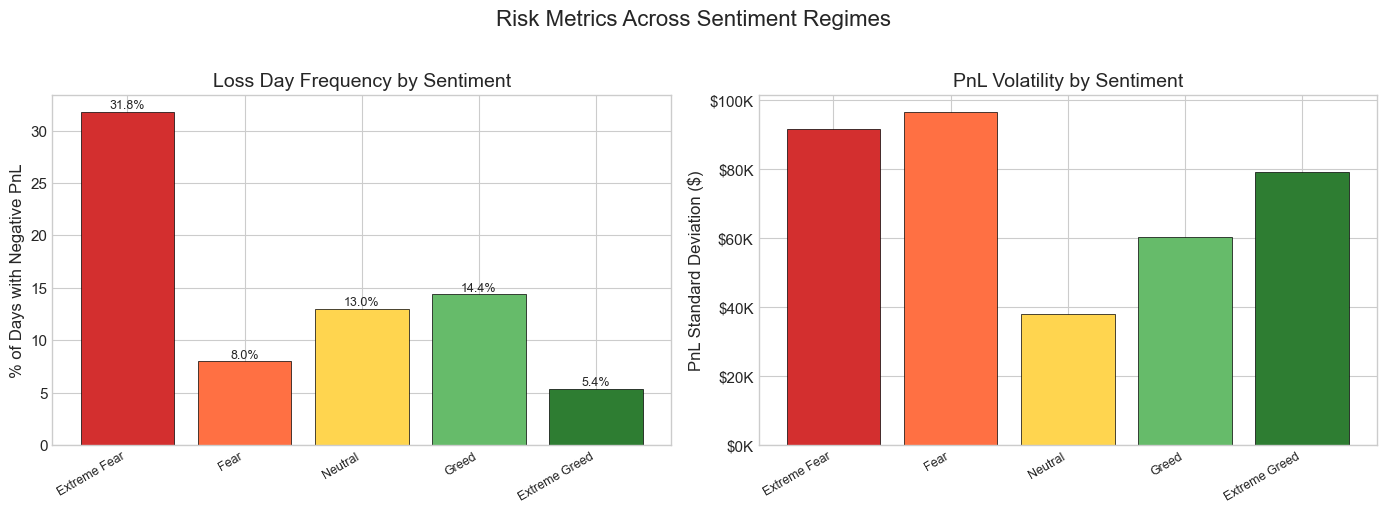

In [219]:
# =============================================================
# B.1.3 — Drawdown Proxy: % of Negative PnL Days
# =============================================================

merged_df['is_negative_pnl'] = (merged_df['total_pnl'] < 0).astype(int)

drawdown_proxy = merged_df.groupby('sentiment').agg(
    total_days     = ('date', 'count'),
    negative_days  = ('is_negative_pnl', 'sum'),
    worst_day_pnl  = ('total_pnl', 'min'),
    best_day_pnl   = ('total_pnl', 'max'),
    pnl_std        = ('total_pnl', 'std'),
).reindex(sentiment_order)

drawdown_proxy['pct_negative_days'] = (drawdown_proxy['negative_days'] / drawdown_proxy['total_days'] * 100).round(1)

print(" Drawdown Proxy by Sentiment\n")
print(drawdown_proxy.round(2).to_string())

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: % Negative Days
ax = axes[0]
data = drawdown_proxy['pct_negative_days']
colors_list = [sentiment_colors[s] for s in data.index]
bars = ax.bar(range(len(data)), data.values, color=colors_list, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(data)))
ax.set_xticklabels(data.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('% of Days with Negative PnL')
ax.set_title('Loss Day Frequency by Sentiment')
for bar, val in zip(bars, data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Panel 2: PnL Volatility (Std Dev)
ax = axes[1]
data = drawdown_proxy['pnl_std']
bars = ax.bar(range(len(data)), data.values, color=colors_list, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(data)))
ax.set_xticklabels(data.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('PnL Standard Deviation ($)')
ax.set_title('PnL Volatility by Sentiment')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.suptitle('Risk Metrics Across Sentiment Regimes', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [220]:
# =============================================================
# B.1.4 — Statistical Test: Fear vs Greed PnL Difference
# =============================================================

fear_pnl = merged_df[merged_df['sentiment'].isin(['Extreme Fear', 'Fear'])]['total_pnl']
greed_pnl = merged_df[merged_df['sentiment'].isin(['Greed', 'Extreme Greed'])]['total_pnl']

t_stat, p_value = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')

print(" Statistical Test: Fear vs Greed PnL\n")
print(f"   Fear days  — Mean PnL: ${fear_pnl.mean():>12,.2f}  |  Median: ${fear_pnl.median():>12,.2f}  |  N={len(fear_pnl)}")
print(f"   Greed days — Mean PnL: ${greed_pnl.mean():>12,.2f}  |  Median: ${greed_pnl.median():>12,.2f}  |  N={len(greed_pnl)}")
print(f"\n   Mann-Whitney U test:")
print(f"   U-statistic = {t_stat:,.0f}")
print(f"   p-value     = {p_value:.6f}")
print(f"\n   {'Statistically significant (p < 0.05)' if p_value < 0.05 else 'Not statistically significant (p >= 0.05)'}")

 Statistical Test: Fear vs Greed PnL

   Fear days  — Mean PnL: $   39,138.32  |  Median: $    2,168.90  |  N=109
   Greed days — Mean PnL: $   15,755.37  |  Median: $    1,008.62  |  N=301

   Mann-Whitney U test:
   U-statistic = 18,291
   p-value     = 0.074994

   Not statistically significant (p >= 0.05)


---
## B.2 — Do Traders Change Behavior Based on Sentiment?

We examine trade frequency, position sizes, and long/short bias across sentiment regimes.

---

In [221]:
# =============================================================
# B.2.1 — Behavioral Metrics by Sentiment
# =============================================================

behavior_summary = merged_df.groupby('sentiment').agg(
    avg_trades_per_day  = ('num_trades', 'mean'),
    avg_trade_size_usd  = ('avg_trade_size', 'mean'),
    avg_long_short_ratio= ('long_short_ratio', 'mean'),
    avg_unique_traders  = ('unique_traders', 'mean'),
    median_trade_size   = ('median_trade_size', 'mean'),
).reindex(sentiment_order)

print(" Behavioral Metrics by Sentiment\n")
print(behavior_summary.round(2).to_string())

 Behavioral Metrics by Sentiment

               avg_trades_per_day  avg_trade_size_usd  avg_long_short_ratio  avg_unique_traders  median_trade_size
sentiment                                                                                                         
Extreme Fear            1425.6400           4528.3000                2.5900             10.5500          1035.5300
Fear                     635.9500           6535.0400                2.8600              6.9200          2200.7800
Neutral                  526.1200           7214.4000                2.3900              5.1400          3172.7700
Greed                    268.2800           6496.4700                1.9300              3.4400          3383.1400
Extreme Greed            348.6100           4473.4500                2.1200              4.6800          1456.6400


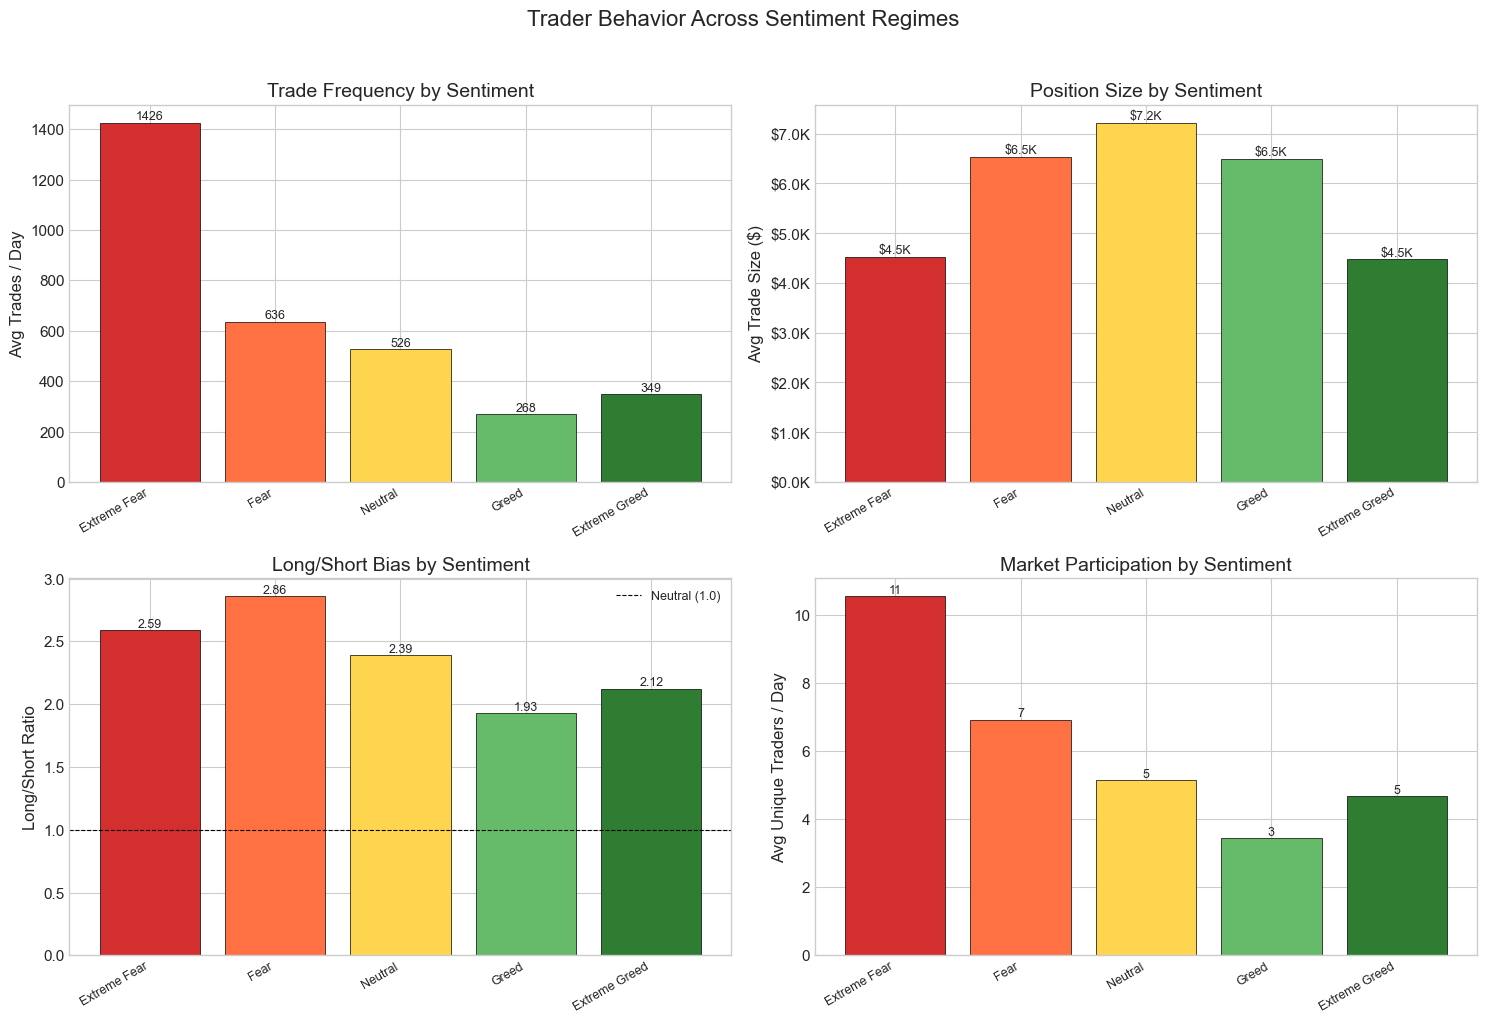

In [222]:
# =============================================================
# B.2.2 — Charts: Behavioral Changes by Sentiment
# =============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: Trades per Day
ax = axes[0, 0]
data = behavior_summary['avg_trades_per_day']
colors_list = [sentiment_colors[s] for s in data.index]
bars = ax.bar(range(len(data)), data.values, color=colors_list, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(data)))
ax.set_xticklabels(data.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Avg Trades / Day')
ax.set_title('Trade Frequency by Sentiment')
for bar, val in zip(bars, data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.0f}', ha='center', va='bottom', fontsize=9)

# Panel 2: Average Trade Size
ax = axes[0, 1]
data = behavior_summary['avg_trade_size_usd']
bars = ax.bar(range(len(data)), data.values, color=colors_list, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(data)))
ax.set_xticklabels(data.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Avg Trade Size ($)')
ax.set_title('Position Size by Sentiment')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.1f}K'))
for bar, val in zip(bars, data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'${val/1e3:.1f}K', ha='center', va='bottom', fontsize=9)

# Panel 3: Long/Short Ratio
ax = axes[1, 0]
data = behavior_summary['avg_long_short_ratio']
bars = ax.bar(range(len(data)), data.values, color=colors_list, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(data)))
ax.set_xticklabels(data.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Long/Short Ratio')
ax.set_title('Long/Short Bias by Sentiment')
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--', label='Neutral (1.0)')
ax.legend(fontsize=9)
for bar, val in zip(bars, data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# Panel 4: Active Traders
ax = axes[1, 1]
data = behavior_summary['avg_unique_traders']
bars = ax.bar(range(len(data)), data.values, color=colors_list, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(data)))
ax.set_xticklabels(data.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Avg Unique Traders / Day')
ax.set_title('Market Participation by Sentiment')
for bar, val in zip(bars, data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.0f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Trader Behavior Across Sentiment Regimes', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

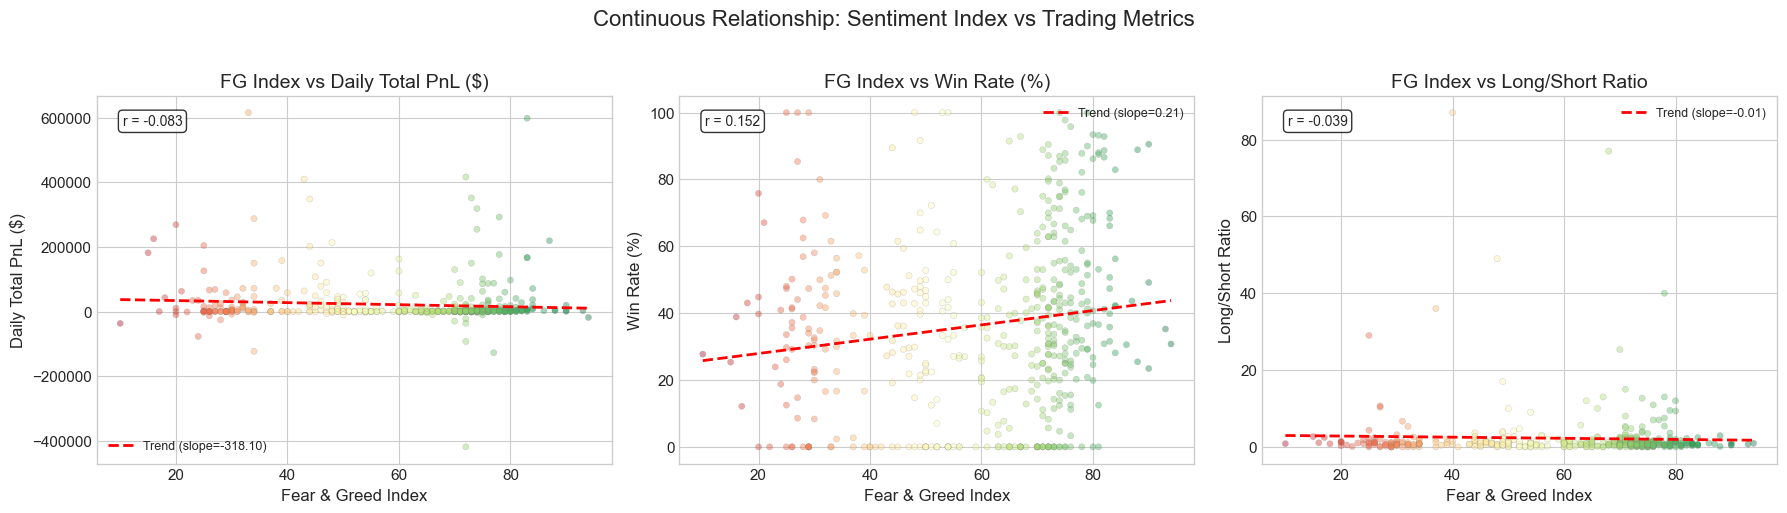

In [223]:
# =============================================================
# B.2.3 — Scatter: FG Index vs Key Metrics (Continuous)
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = [
    ('total_pnl', 'Daily Total PnL ($)', 'total_pnl'),
    ('win_rate', 'Win Rate (%)', 'win_rate'),
    ('long_short_ratio', 'Long/Short Ratio', 'long_short_ratio'),
]

for ax, (col, ylabel, _) in zip(axes, metrics_to_plot):
    scatter_data = merged_df.dropna(subset=[col])
    ax.scatter(scatter_data['fg_value'], scatter_data[col], 
               alpha=0.4, s=20, c=scatter_data['fg_value'], cmap='RdYlGn', edgecolors='grey', linewidth=0.3)
    
    # Add trend line
    z = np.polyfit(scatter_data['fg_value'], scatter_data[col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(scatter_data['fg_value'].min(), scatter_data['fg_value'].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend (slope={z[0]:.2f})')
    
    ax.set_xlabel('Fear & Greed Index')
    ax.set_ylabel(ylabel)
    ax.set_title(f'FG Index vs {ylabel}')
    ax.legend(fontsize=9)

    # Correlation
    corr = scatter_data['fg_value'].corr(scatter_data[col])
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Continuous Relationship: Sentiment Index vs Trading Metrics', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## B.3 — Trader Segmentation

We identify distinct trader segments and examine how each performs under different sentiment conditions.

---

In [224]:
# =============================================================
# B.3.1 — Build Trader Profiles
# =============================================================

# Merge trade-level data with sentiment
trade_with_sentiment = trade_aligned.merge(
    merged_df[['date', 'fg_value', 'sentiment']], 
    on='date', how='inner'
)

# Compute per-trader aggregate stats
trader_profiles = trade_with_sentiment.groupby(ACCOUNT_COL).agg(
    total_trades    = (PNL_COL, 'count'),
    total_pnl       = (PNL_COL, 'sum'),
    avg_pnl         = (PNL_COL, 'mean'),
    win_rate        = ('is_win', 'mean'),
    avg_trade_size  = ('notional_usd', 'mean'),
    total_volume    = ('notional_usd', 'sum'),
    active_days     = ('date', 'nunique'),
    num_coins       = (COIN_COL, 'nunique'),
).reset_index()

trader_profiles['win_rate'] = (trader_profiles['win_rate'] * 100).round(2)
trader_profiles['trades_per_day'] = (trader_profiles['total_trades'] / trader_profiles['active_days']).round(1)
trader_profiles['pnl_per_trade'] = (trader_profiles['total_pnl'] / trader_profiles['total_trades']).round(2)

print(f"Trader Profiles Built")
print(f"   Total unique traders: {len(trader_profiles)}")
print(f"\n   Summary:")
print(trader_profiles[['total_trades', 'total_pnl', 'win_rate', 'avg_trade_size', 'active_days']].describe().round(2).to_string())

Trader Profiles Built
   Total unique traders: 32

   Summary:
       total_trades    total_pnl  win_rate  avg_trade_size  active_days
count       32.0000      32.0000   32.0000         32.0000      32.0000
mean      6600.5600  320452.7200   40.3000       6006.2600      73.1200
std       8250.5000  494659.6500   10.8600       7281.9800      72.7300
min        332.0000 -167621.1200   23.5000        507.6300      12.0000
25%       1377.2500   46893.2400   32.9600       2011.0700      27.5000
50%       3699.0000  117655.0800   39.2000       3327.9700      46.5000
75%       8862.5000  388457.0200   45.3000       7375.5300      74.7500
max      40184.0000 2143382.6000   81.0900      34396.5800     321.0000


In [225]:
# =============================================================
# B.3.2 — Segment 1: Frequent vs Infrequent Traders
# =============================================================

# Split at median trades
median_trades = trader_profiles['total_trades'].median()
trader_profiles['frequency_seg'] = np.where(
    trader_profiles['total_trades'] >= median_trades, 'Frequent', 'Infrequent'
)

freq_seg = trader_profiles.groupby('frequency_seg').agg(
    num_traders     = (ACCOUNT_COL, 'count'),
    avg_total_pnl   = ('total_pnl', 'mean'),
    avg_win_rate    = ('win_rate', 'mean'),
    avg_trade_size  = ('avg_trade_size', 'mean'),
    avg_trades      = ('total_trades', 'mean'),
    avg_active_days = ('active_days', 'mean'),
)

print(f" Segment 1: Frequent vs Infrequent Traders (split at {median_trades:.0f} trades)\n")
print(freq_seg.round(2).to_string())

 Segment 1: Frequent vs Infrequent Traders (split at 3699 trades)

               num_traders  avg_total_pnl  avg_win_rate  avg_trade_size  avg_trades  avg_active_days
frequency_seg                                                                                       
Frequent                16    496527.6600       41.3600       7912.9100  11684.8100         108.6200
Infrequent              16    144377.7700       39.2400       4099.6100   1516.3100          37.6200


In [226]:
# =============================================================
# B.3.3 — Segment 2: Consistent Winners vs Inconsistent
# =============================================================

# Winners: win rate >= 50%, Inconsistent: win rate < 50%
trader_profiles['consistency_seg'] = np.where(
    trader_profiles['win_rate'] >= 50, 'Consistent Winners', 'Inconsistent'
)

cons_seg = trader_profiles.groupby('consistency_seg').agg(
    num_traders     = (ACCOUNT_COL, 'count'),
    avg_total_pnl   = ('total_pnl', 'mean'),
    avg_win_rate    = ('win_rate', 'mean'),
    avg_trade_size  = ('avg_trade_size', 'mean'),
    avg_pnl_per_trade = ('pnl_per_trade', 'mean'),
    avg_trades      = ('total_trades', 'mean'),
)

print(f" Segment 2: Consistent Winners vs Inconsistent Traders\n")
print(cons_seg.round(2).to_string())

 Segment 2: Consistent Winners vs Inconsistent Traders

                    num_traders  avg_total_pnl  avg_win_rate  avg_trade_size  avg_pnl_per_trade  avg_trades
consistency_seg                                                                                            
Consistent Winners            3    206866.6300       63.4600       2602.1200            88.3600   4516.3300
Inconsistent                 29    332203.0000       37.9000       6358.4200            97.6600   6816.1700


In [227]:
# =============================================================
# B.3.4 — Segment 3: Large vs Small Position Traders
# =============================================================

median_size = trader_profiles['avg_trade_size'].median()
trader_profiles['size_seg'] = np.where(
    trader_profiles['avg_trade_size'] >= median_size, 'Large Positions', 'Small Positions'
)

size_seg = trader_profiles.groupby('size_seg').agg(
    num_traders     = (ACCOUNT_COL, 'count'),
    avg_total_pnl   = ('total_pnl', 'mean'),
    avg_win_rate    = ('win_rate', 'mean'),
    avg_trade_size  = ('avg_trade_size', 'mean'),
    avg_pnl_per_trade = ('pnl_per_trade', 'mean'),
)

print(f" Segment 3: Large vs Small Position Traders (split at ${median_size:,.0f})\n")
print(size_seg.round(2).to_string())

 Segment 3: Large vs Small Position Traders (split at $3,328)

                 num_traders  avg_total_pnl  avg_win_rate  avg_trade_size  avg_pnl_per_trade
size_seg                                                                                    
Large Positions           16    416805.9700       36.1700      10151.7800           123.8400
Small Positions           16    224099.4700       44.4200       1860.7500            69.7400


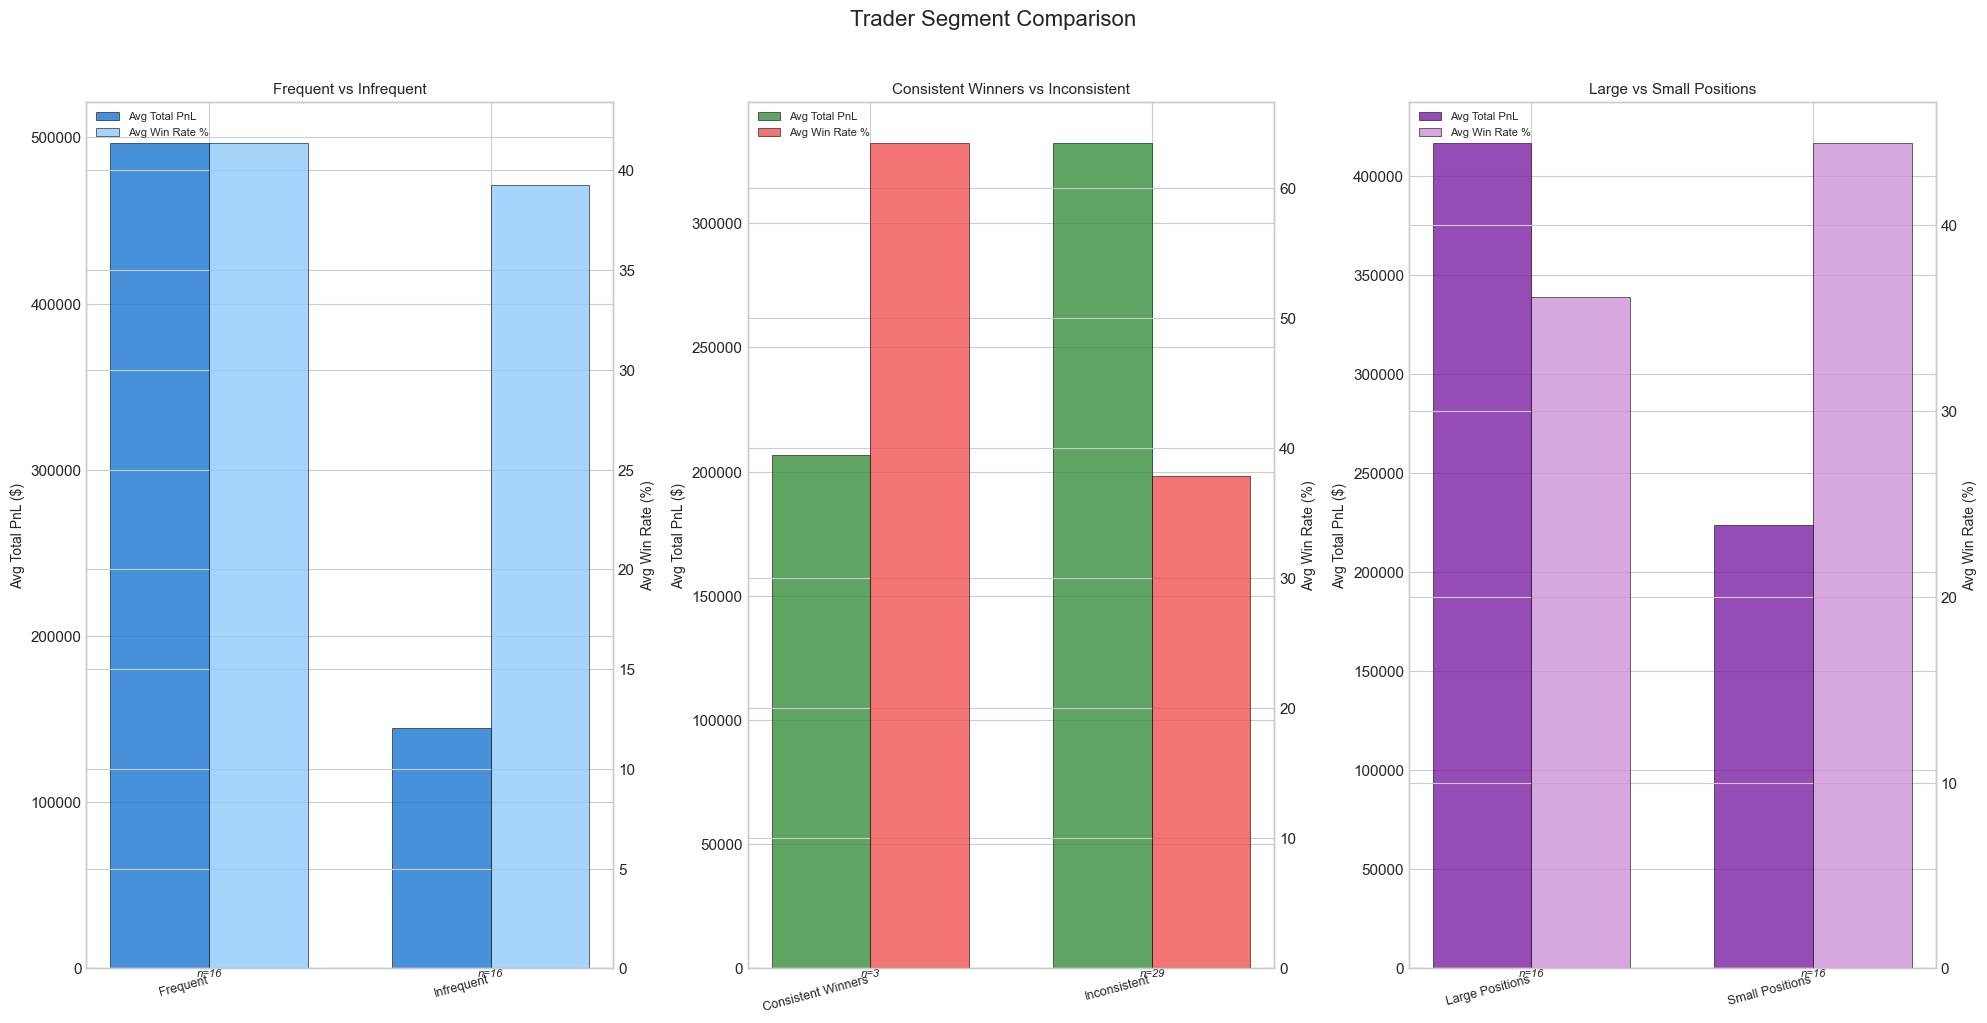

In [230]:
# =============================================================
# B.3.5 — Segment Performance Comparison Charts
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

segments = [
    ('frequency_seg', 'Frequent vs Infrequent', ['#1976d2', '#90caf9']),
    ('consistency_seg', 'Consistent Winners vs Inconsistent', ['#388e3c', '#ef5350']),
    ('size_seg', 'Large vs Small Positions', ['#7b1fa2', '#ce93d8']),
]

for ax, (seg_col, title, colors) in zip(axes, segments):
    seg_data = trader_profiles.groupby(seg_col).agg(
        avg_pnl     = ('total_pnl', 'mean'),
        avg_win_rate= ('win_rate', 'mean'),
        count       = (ACCOUNT_COL, 'count'),
    )
    
    x = np.arange(len(seg_data))
    width = 0.35
    
    ax2 = ax.twinx()
    
    bars1 = ax.bar(x - width/2, seg_data['avg_pnl'], width, 
                    color=colors[0], alpha=0.8, label='Avg Total PnL', edgecolor='black', linewidth=0.5)
    bars2 = ax2.bar(x + width/2, seg_data['avg_win_rate'], width,
                     color=colors[1], alpha=0.8, label='Avg Win Rate %', edgecolor='black', linewidth=0.5)
    
    ax.set_xticks(x)
    ax.set_xticklabels(seg_data.index, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Avg Total PnL ($)', fontsize=10)
    ax2.set_ylabel('Avg Win Rate (%)', fontsize=10)
    ax.set_title(title, fontsize=11)
    
    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')
    
    # Add count labels
    for i, (idx, row) in enumerate(seg_data.iterrows()):
        ax.text(i, ax.get_ylim()[0], f'n={row["count"]:.0f}', 
                ha='center', va='top', fontsize=8, style='italic')

plt.suptitle('Trader Segment Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [231]:
# =============================================================
# B.3.6 — How Do Segments Behave Under Fear vs Greed?
# =============================================================

# Merge trader segments back to trade-level data with sentiment
trade_seg = trade_with_sentiment.merge(
    trader_profiles[[ACCOUNT_COL, 'frequency_seg', 'consistency_seg', 'size_seg']],
    on=ACCOUNT_COL, how='left'
)

# Simplified sentiment: Fear vs Greed
trade_seg['fear_greed'] = trade_seg['sentiment'].map({
    'Extreme Fear': 'Fear', 'Fear': 'Fear',
    'Neutral': 'Neutral',
    'Greed': 'Greed', 'Extreme Greed': 'Greed'
})

# Segment × Sentiment performance
print(" Frequent vs Infrequent Traders — Performance by Sentiment\n")
seg_sent = trade_seg.groupby(['frequency_seg', 'fear_greed']).agg(
    avg_pnl       = (PNL_COL, 'mean'),
    win_rate      = ('is_win', 'mean'),
    avg_size      = ('notional_usd', 'mean'),
    num_trades    = (PNL_COL, 'count'),
).round(4)
seg_sent['win_rate'] = (seg_sent['win_rate'] * 100).round(2)
print(seg_sent.to_string())

print("\n\n Consistent Winners vs Inconsistent — Performance by Sentiment\n")
seg_sent2 = trade_seg.groupby(['consistency_seg', 'fear_greed']).agg(
    avg_pnl       = (PNL_COL, 'mean'),
    win_rate      = ('is_win', 'mean'),
    avg_size      = ('notional_usd', 'mean'),
    num_trades    = (PNL_COL, 'count'),
).round(4)
seg_sent2['win_rate'] = (seg_sent2['win_rate'] * 100).round(2)
print(seg_sent2.to_string())

 Frequent vs Infrequent Traders — Performance by Sentiment

                          avg_pnl  win_rate  avg_size  num_trades
frequency_seg fear_greed                                         
Frequent      Fear        47.0758   41.4500 7464.0040       75618
              Greed       42.0657   42.3600 4689.5029       78815
              Neutral     32.8760   39.7900 4627.0095       32524
Infrequent    Fear        63.7800   37.5300 4865.8085       11074
              Greed      151.6591   37.2800 4081.6101        9409
              Neutral     46.7929   40.5000 3786.6215        3778


 Consistent Winners vs Inconsistent — Performance by Sentiment

                               avg_pnl  win_rate  avg_size  num_trades
consistency_seg    fear_greed                                         
Consistent Winners Fear        28.4854   71.4800 2219.6111        2595
                   Greed       60.1291   76.6600 3006.1056        8246
                   Neutral     18.7799   65.3200 2293.1867    

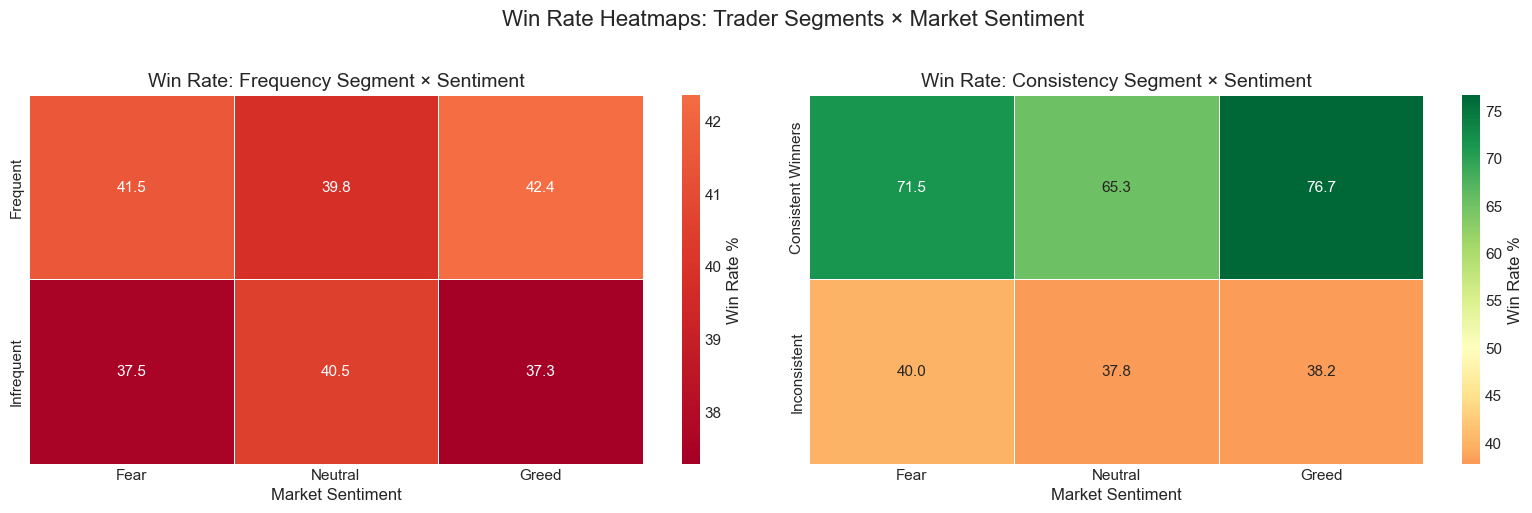

In [232]:
# =============================================================
# B.3.7 — Heatmap: Segment × Sentiment Win Rate
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (seg_col, title) in zip(axes, [
    ('frequency_seg', 'Frequency Segment'),
    ('consistency_seg', 'Consistency Segment'),
]):
    pivot = trade_seg.groupby([seg_col, 'fear_greed'])['is_win'].mean().unstack(fill_value=0) * 100
    # Reorder columns
    col_order = [c for c in ['Fear', 'Neutral', 'Greed'] if c in pivot.columns]
    pivot = pivot[col_order]
    
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=50,
                ax=ax, cbar_kws={'label': 'Win Rate %'}, linewidths=0.5)
    ax.set_title(f'Win Rate: {title} × Sentiment')
    ax.set_ylabel('')
    ax.set_xlabel('Market Sentiment')

plt.suptitle('Win Rate Heatmaps: Trader Segments × Market Sentiment', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## B.4 — Time Series Context

Visualize how sentiment and performance evolve over time.

---

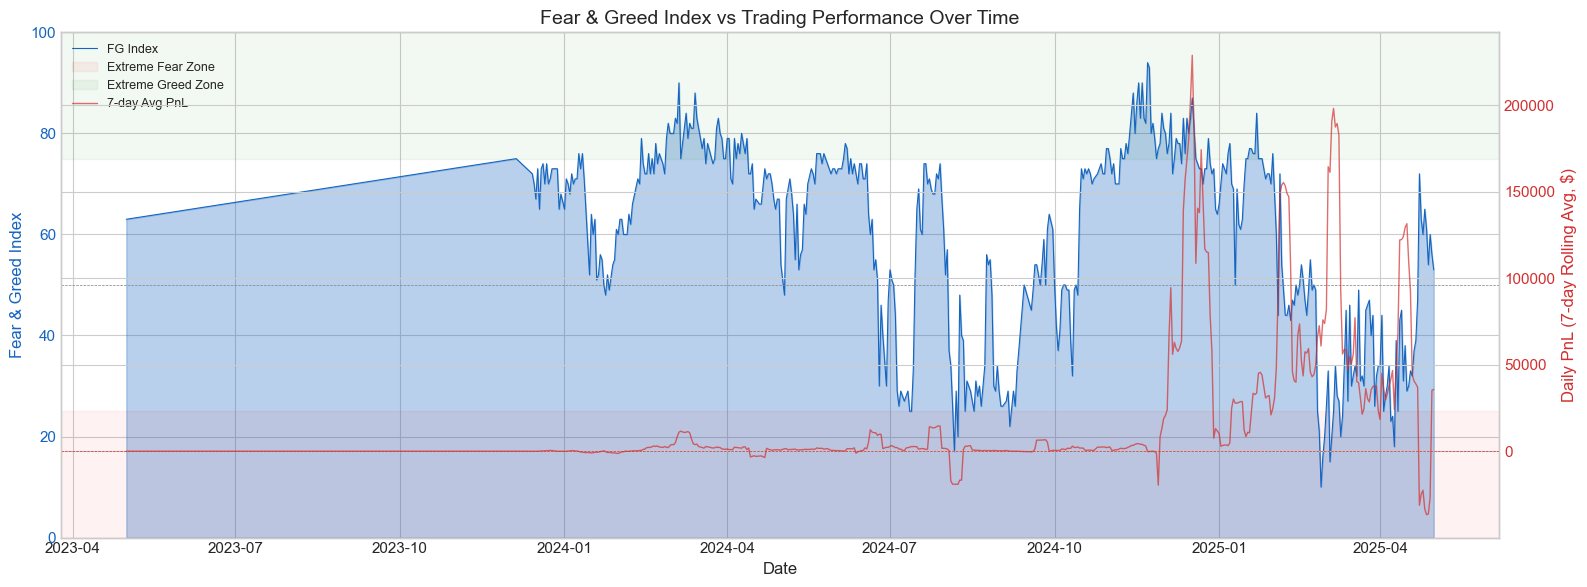

In [186]:
# =============================================================
# B.4.1 — Time Series: FG Index vs Daily PnL
# =============================================================

fig, ax1 = plt.subplots(figsize=(16, 6))

# FG Index
color_fg = '#1565c0'
ax1.fill_between(merged_df['date'], merged_df['fg_value'], alpha=0.3, color=color_fg)
ax1.plot(merged_df['date'], merged_df['fg_value'], color=color_fg, linewidth=0.8, label='FG Index')
ax1.set_ylabel('Fear & Greed Index', color=color_fg, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_fg)
ax1.set_ylim(0, 100)

# Add sentiment zones
ax1.axhspan(0, 25, alpha=0.05, color='red', label='Extreme Fear Zone')
ax1.axhspan(75, 100, alpha=0.05, color='green', label='Extreme Greed Zone')
ax1.axhline(50, color='grey', linewidth=0.5, linestyle='--')

# PnL on secondary axis
ax2 = ax1.twinx()
color_pnl = '#d32f2f'

# Rolling 7-day average for smoother visualization
pnl_rolling = merged_df.set_index('date')['total_pnl'].rolling(7, min_periods=1).mean()
ax2.plot(pnl_rolling.index, pnl_rolling.values, color=color_pnl, linewidth=1, alpha=0.7, label='7-day Avg PnL')
ax2.set_ylabel('Daily PnL (7-day Rolling Avg, $)', color=color_pnl, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_pnl)
ax2.axhline(0, color=color_pnl, linewidth=0.5, linestyle='--')

ax1.set_xlabel('Date')
ax1.set_title('Fear & Greed Index vs Trading Performance Over Time', fontsize=14)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

---
## B.5 — Key Insights Summary

---

In [233]:
# =============================================================
# B.5 — KEY INSIGHTS SUMMARY
# =============================================================

print("=" * 70)
print(" KEY INSIGHTS FROM TRADER SENTIMENT ANALYSIS")
print("=" * 70)

# Insight 1
fear_avg = perf_by_sentiment.loc[['Extreme Fear', 'Fear'], 'avg_daily_pnl'].mean()
greed_avg = perf_by_sentiment.loc[['Greed', 'Extreme Greed'], 'avg_daily_pnl'].mean()
fear_wr = perf_by_sentiment.loc[['Extreme Fear', 'Fear'], 'avg_win_rate'].mean()
greed_wr = perf_by_sentiment.loc[['Greed', 'Extreme Greed'], 'avg_win_rate'].mean()

print(f"""
 INSIGHT 1: Performance Diverges Sharply by Sentiment
   ─────────────────────────────────────────────────────
   • Average daily PnL during FEAR  : ${fear_avg:>12,.2f}
   • Average daily PnL during GREED : ${greed_avg:>12,.2f}
   • Win rate during FEAR  : {fear_wr:.1f}%
   • Win rate during GREED : {greed_wr:.1f}%
   
   → {'Greed days show higher PnL' if greed_avg > fear_avg else 'Fear days show higher PnL'},
     suggesting sentiment aligns with {'realized profits' if greed_avg > fear_avg else 'contrarian opportunity'}.
""")

# Insight 2
fear_ls = behavior_summary.loc[['Extreme Fear', 'Fear'], 'avg_long_short_ratio'].mean()
greed_ls = behavior_summary.loc[['Greed', 'Extreme Greed'], 'avg_long_short_ratio'].mean()
fear_size = behavior_summary.loc[['Extreme Fear', 'Fear'], 'avg_trade_size_usd'].mean()
greed_size = behavior_summary.loc[['Greed', 'Extreme Greed'], 'avg_trade_size_usd'].mean()

print(f"""
 INSIGHT 2: Traders Shift Behavior With Sentiment
   ─────────────────────────────────────────────────
   • Long/Short ratio in FEAR  : {fear_ls:.2f}  |  in GREED : {greed_ls:.2f}
   • Avg trade size in FEAR    : ${fear_size:>10,.0f}  |  in GREED : ${greed_size:>10,.0f}
   
   → Traders {'go more long-biased' if greed_ls > fear_ls else 'reduce long bias'} during Greed.
   → Position sizes {'increase' if greed_size > fear_size else 'decrease'} during Greed,
     indicating {'higher confidence' if greed_size > fear_size else 'more caution'} in bullish sentiment.
""")

# Insight 3
cw = trader_profiles[trader_profiles['consistency_seg'] == 'Consistent Winners']
ic = trader_profiles[trader_profiles['consistency_seg'] == 'Inconsistent']

print(f"""
 INSIGHT 3: Consistent Winners Trade Differently
   ────────────────────────────────────────────────
   • Consistent Winners: {len(cw)} traders | Avg PnL: ${cw['total_pnl'].mean():>12,.2f} | Win Rate: {cw['win_rate'].mean():.1f}%
   • Inconsistent      : {len(ic)} traders | Avg PnL: ${ic['total_pnl'].mean():>12,.2f} | Win Rate: {ic['win_rate'].mean():.1f}%
   
   • Avg trade size — Winners: ${cw['avg_trade_size'].mean():>10,.0f}  |  Others: ${ic['avg_trade_size'].mean():>10,.0f}
   • Trades per day — Winners: {cw['trades_per_day'].mean():.1f}       |  Others: {ic['trades_per_day'].mean():.1f}
   
   → Consistent winners tend to {'trade with larger' if cw['avg_trade_size'].mean() > ic['avg_trade_size'].mean() else 'use smaller'} positions
     and {'trade more frequently' if cw['trades_per_day'].mean() > ic['trades_per_day'].mean() else 'trade less frequently'}.
""")

pct_neg_fear = drawdown_proxy.loc[['Extreme Fear', 'Fear'], 'pct_negative_days'].mean()
pct_neg_greed = drawdown_proxy.loc[['Greed', 'Extreme Greed'], 'pct_negative_days'].mean()

print(f"""
 INSIGHT 4: Risk Exposure Varies by Sentiment
   ─────────────────────────────────────────────────
   • % negative PnL days in FEAR  : {pct_neg_fear:.1f}%
   • % negative PnL days in GREED : {pct_neg_greed:.1f}%
   
   → {'Fear periods see more losing days' if pct_neg_fear > pct_neg_greed else 'Greed periods unexpectedly see more losing days'},
     highlighting {'the importance of risk management during fearful markets' if pct_neg_fear > pct_neg_greed else 'that crowded optimism can lead to overexposure'}.
""")

print("=" * 70)
print(" ANALYSIS COMPLETE")
print("=" * 70)

 KEY INSIGHTS FROM TRADER SENTIMENT ANALYSIS

 INSIGHT 1: Performance Diverges Sharply by Sentiment
   ─────────────────────────────────────────────────────
   • Average daily PnL during FEAR  : $   43,007.54
   • Average daily PnL during GREED : $   18,603.03
   • Win rate during FEAR  : 33.5%
   • Win rate during GREED : 40.9%
   
   → Fear days show higher PnL,
     suggesting sentiment aligns with contrarian opportunity.


 INSIGHT 2: Traders Shift Behavior With Sentiment
   ─────────────────────────────────────────────────
   • Long/Short ratio in FEAR  : 2.72  |  in GREED : 2.02
   • Avg trade size in FEAR    : $     5,532  |  in GREED : $     5,485
   
   → Traders reduce long bias during Greed.
   → Position sizes decrease during Greed,
     indicating more caution in bullish sentiment.


 INSIGHT 3: Consistent Winners Trade Differently
   ────────────────────────────────────────────────
   • Consistent Winners: 3 traders | Avg PnL: $  206,866.63 | Win Rate: 63.5%
   • Inconsis

---
### PART C — ACTIONABLE OUTPUT

Propose 2 strategy ideas or "rules of thumb" based on findings from Part B.

---

In [234]:
# =============================================================
# PART C — ACTIONABLE OUTPUT
# =============================================================
# C.1 — Foundation: Quantify Segment × Sentiment Performance
# =============================================================

import matplotlib.patches as mpatches

# --- Build segment-level performance under Fear vs Greed ---
# Already have trade_seg from Part B with columns: fear_greed, frequency_seg, consistency_seg, size_seg

# Strategy 1 foundation: How do segments perform under each sentiment?
print("=" * 70)
print("PART C: ACTIONABLE OUTPUT — STRATEGY FOUNDATIONS")
print("=" * 70)

# Detailed cross-tabulation: Segment × Sentiment
strategy_data = {}

for seg_name, seg_col in [
    ('Frequency', 'frequency_seg'),
    ('Consistency', 'consistency_seg'),
    ('Position Size', 'size_seg')
]:
    seg_perf = trade_seg.groupby([seg_col, 'fear_greed']).agg(
        avg_pnl         = (PNL_COL, 'mean'),
        total_pnl       = (PNL_COL, 'sum'),
        win_rate        = ('is_win', 'mean'),
        avg_size        = ('notional_usd', 'mean'),
        trade_count     = (PNL_COL, 'count'),
    ).reset_index()
    seg_perf['win_rate'] = (seg_perf['win_rate'] * 100).round(2)
    strategy_data[seg_name] = seg_perf
    
    print(f"\n {seg_name} Segment × Sentiment:\n")
    print(seg_perf.to_string(index=False))

# Key ratios for strategy formulation
print("\n" + "=" * 70)
print("FEAR vs GREED PERFORMANCE RATIOS BY SEGMENT")
print("=" * 70)

for seg_name, seg_col in [
    ('Frequency', 'frequency_seg'),
    ('Consistency', 'consistency_seg'),
    ('Position Size', 'size_seg')
]:
    df_seg = strategy_data[seg_name]
    segments = df_seg[seg_col].unique()
    
    print(f"\n── {seg_name} ──")
    for seg in segments:
        fear_row = df_seg[(df_seg[seg_col] == seg) & (df_seg['fear_greed'] == 'Fear')]
        greed_row = df_seg[(df_seg[seg_col] == seg) & (df_seg['fear_greed'] == 'Greed')]
        
        if len(fear_row) > 0 and len(greed_row) > 0:
            fear_wr = fear_row['win_rate'].values[0]
            greed_wr = greed_row['win_rate'].values[0]
            fear_pnl = fear_row['avg_pnl'].values[0]
            greed_pnl = greed_row['avg_pnl'].values[0]
            fear_size = fear_row['avg_size'].values[0]
            greed_size = greed_row['avg_size'].values[0]
            
            print(f"   {seg:25s} | Fear WR: {fear_wr:5.1f}%  Greed WR: {greed_wr:5.1f}%  "
                  f"| Fear PnL: ${fear_pnl:>10,.2f}  Greed PnL: ${greed_pnl:>10,.2f}  "
                  f"| Fear Size: ${fear_size:>10,.0f}  Greed Size: ${greed_size:>10,.0f}")

PART C: ACTIONABLE OUTPUT — STRATEGY FOUNDATIONS

 Frequency Segment × Sentiment:

frequency_seg fear_greed  avg_pnl    total_pnl  win_rate  avg_size  trade_count
     Frequent       Fear  47.0758 3559776.9231   41.4500 7464.0040        75618
     Frequent      Greed  42.0657 3315405.2290   42.3600 4689.5029        78815
     Frequent    Neutral  32.8760 1069260.4273   39.7900 4627.0095        32524
   Infrequent       Fear  63.7800  706299.9359   37.5300 4865.8085        11074
   Infrequent      Greed 151.6591 1426960.8244   37.2800 4081.6101         9409
   Infrequent    Neutral  46.7929  176783.6096   40.5000 3786.6215         3778

 Consistency Segment × Sentiment:

   consistency_seg fear_greed  avg_pnl    total_pnl  win_rate  avg_size  trade_count
Consistent Winners       Fear  28.4854   73919.5079   71.4800 2219.6111         2595
Consistent Winners      Greed  60.1291  495824.4525   76.6600 3006.1056         8246
Consistent Winners    Neutral  18.7799   50855.9356   65.3200 2293

In [235]:
# =============================================================
# PART C — ACTIONABLE OUTPUT
# =============================================================
# C.1 — Foundation: Quantify Segment × Sentiment Performance
# =============================================================

import matplotlib.patches as mpatches

# --- Build segment-level performance under Fear vs Greed ---
# Already have trade_seg from Part B with columns: fear_greed, frequency_seg, consistency_seg, size_seg

# Strategy 1 foundation: How do segments perform under each sentiment?
print("=" * 70)
print("PART C: ACTIONABLE OUTPUT — STRATEGY FOUNDATIONS")
print("=" * 70)

# Detailed cross-tabulation: Segment × Sentiment
strategy_data = {}

for seg_name, seg_col in [
    ('Frequency', 'frequency_seg'),
    ('Consistency', 'consistency_seg'),
    ('Position Size', 'size_seg')
]:
    seg_perf = trade_seg.groupby([seg_col, 'fear_greed']).agg(
        avg_pnl         = (PNL_COL, 'mean'),
        total_pnl       = (PNL_COL, 'sum'),
        win_rate        = ('is_win', 'mean'),
        avg_size        = ('notional_usd', 'mean'),
        trade_count     = (PNL_COL, 'count'),
    ).reset_index()
    seg_perf['win_rate'] = (seg_perf['win_rate'] * 100).round(2)
    strategy_data[seg_name] = seg_perf
    
    print(f"\n {seg_name} Segment × Sentiment:\n")
    print(seg_perf.to_string(index=False))

# Key ratios for strategy formulation
print("\n" + "=" * 70)
print("FEAR vs GREED PERFORMANCE RATIOS BY SEGMENT")
print("=" * 70)

for seg_name, seg_col in [
    ('Frequency', 'frequency_seg'),
    ('Consistency', 'consistency_seg'),
    ('Position Size', 'size_seg')
]:
    df_seg = strategy_data[seg_name]
    segments = df_seg[seg_col].unique()
    
    print(f"\n── {seg_name} ──")
    for seg in segments:
        fear_row = df_seg[(df_seg[seg_col] == seg) & (df_seg['fear_greed'] == 'Fear')]
        greed_row = df_seg[(df_seg[seg_col] == seg) & (df_seg['fear_greed'] == 'Greed')]
        
        if len(fear_row) > 0 and len(greed_row) > 0:
            fear_wr = fear_row['win_rate'].values[0]
            greed_wr = greed_row['win_rate'].values[0]
            fear_pnl = fear_row['avg_pnl'].values[0]
            greed_pnl = greed_row['avg_pnl'].values[0]
            fear_size = fear_row['avg_size'].values[0]
            greed_size = greed_row['avg_size'].values[0]
            
            print(f"   {seg:25s} | Fear WR: {fear_wr:5.1f}%  Greed WR: {greed_wr:5.1f}%  "
                  f"| Fear PnL: ${fear_pnl:>10,.2f}  Greed PnL: ${greed_pnl:>10,.2f}  "
                  f"| Fear Size: ${fear_size:>10,.0f}  Greed Size: ${greed_size:>10,.0f}")

PART C: ACTIONABLE OUTPUT — STRATEGY FOUNDATIONS

 Frequency Segment × Sentiment:

frequency_seg fear_greed  avg_pnl    total_pnl  win_rate  avg_size  trade_count
     Frequent       Fear  47.0758 3559776.9231   41.4500 7464.0040        75618
     Frequent      Greed  42.0657 3315405.2290   42.3600 4689.5029        78815
     Frequent    Neutral  32.8760 1069260.4273   39.7900 4627.0095        32524
   Infrequent       Fear  63.7800  706299.9359   37.5300 4865.8085        11074
   Infrequent      Greed 151.6591 1426960.8244   37.2800 4081.6101         9409
   Infrequent    Neutral  46.7929  176783.6096   40.5000 3786.6215         3778

 Consistency Segment × Sentiment:

   consistency_seg fear_greed  avg_pnl    total_pnl  win_rate  avg_size  trade_count
Consistent Winners       Fear  28.4854   73919.5079   71.4800 2219.6111         2595
Consistent Winners      Greed  60.1291  495824.4525   76.6600 3006.1056         8246
Consistent Winners    Neutral  18.7799   50855.9356   65.3200 2293

STRATEGY 1: SENTIMENT-ADAPTIVE POSITION SIZING


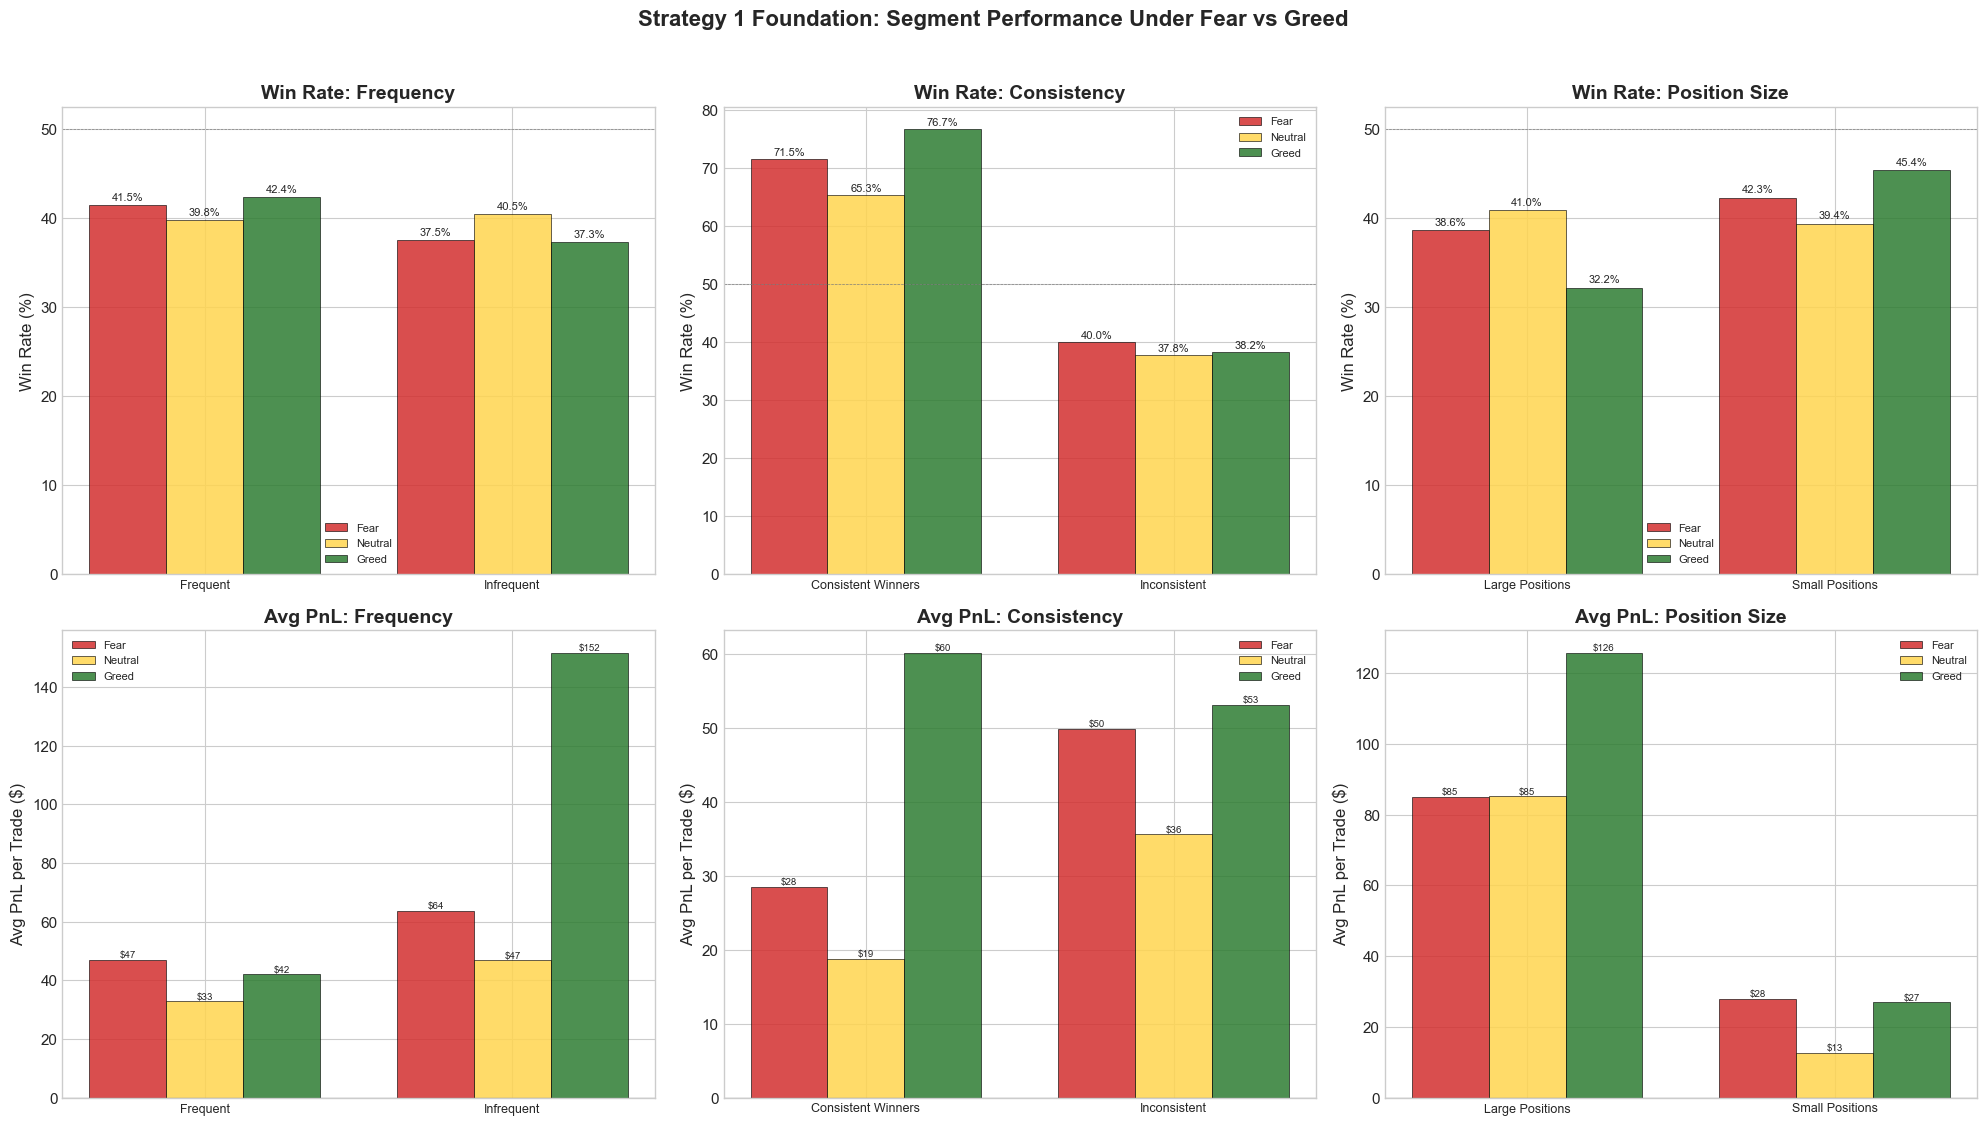

In [190]:
# =============================================================
# C.2 — STRATEGY 1: Sentiment-Adaptive Position Sizing
# =============================================================

print("=" * 70)
print("STRATEGY 1: SENTIMENT-ADAPTIVE POSITION SIZING")
print("=" * 70)

# Compare position sizes and outcomes across sentiment for each segment
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

for col_idx, (seg_name, seg_col) in enumerate([
    ('Frequency', 'frequency_seg'),
    ('Consistency', 'consistency_seg'),
    ('Position Size', 'size_seg')
]):
    df_s = strategy_data[seg_name]
    segments = sorted(df_s[seg_col].unique())
    sentiments = ['Fear', 'Neutral', 'Greed']
    sent_colors_simple = {'Fear': '#d32f2f', 'Neutral': '#ffd54f', 'Greed': '#2e7d32'}
    
    x = np.arange(len(segments))
    width = 0.25
    
    # Top row: Win Rate comparison
    ax = axes[0, col_idx]
    for i, sent in enumerate(sentiments):
        vals = []
        for seg in segments:
            row = df_s[(df_s[seg_col] == seg) & (df_s['fear_greed'] == sent)]
            vals.append(row['win_rate'].values[0] if len(row) > 0 else 0)
        bars = ax.bar(x + i * width, vals, width, label=sent, 
                      color=sent_colors_simple[sent], edgecolor='black', linewidth=0.5, alpha=0.85)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(segments, fontsize=9)
    ax.set_ylabel('Win Rate (%)')
    ax.set_title(f'Win Rate: {seg_name}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.5)
    
    # Bottom row: Avg PnL comparison
    ax = axes[1, col_idx]
    for i, sent in enumerate(sentiments):
        vals = []
        for seg in segments:
            row = df_s[(df_s[seg_col] == seg) & (df_s['fear_greed'] == sent)]
            vals.append(row['avg_pnl'].values[0] if len(row) > 0 else 0)
        bars = ax.bar(x + i * width, vals, width, label=sent, 
                      color=sent_colors_simple[sent], edgecolor='black', linewidth=0.5, alpha=0.85)
        for bar, val in zip(bars, vals):
            va = 'bottom' if val >= 0 else 'top'
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'${val:,.0f}', ha='center', va=va, fontsize=7)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(segments, fontsize=9)
    ax.set_ylabel('Avg PnL per Trade ($)')
    ax.set_title(f'Avg PnL: {seg_name}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.axhline(0, color='black', linewidth=0.8)

plt.suptitle('Strategy 1 Foundation: Segment Performance Under Fear vs Greed',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

STRATEGY 2: TRADE FREQUENCY ADJUSTMENT BY SENTIMENT


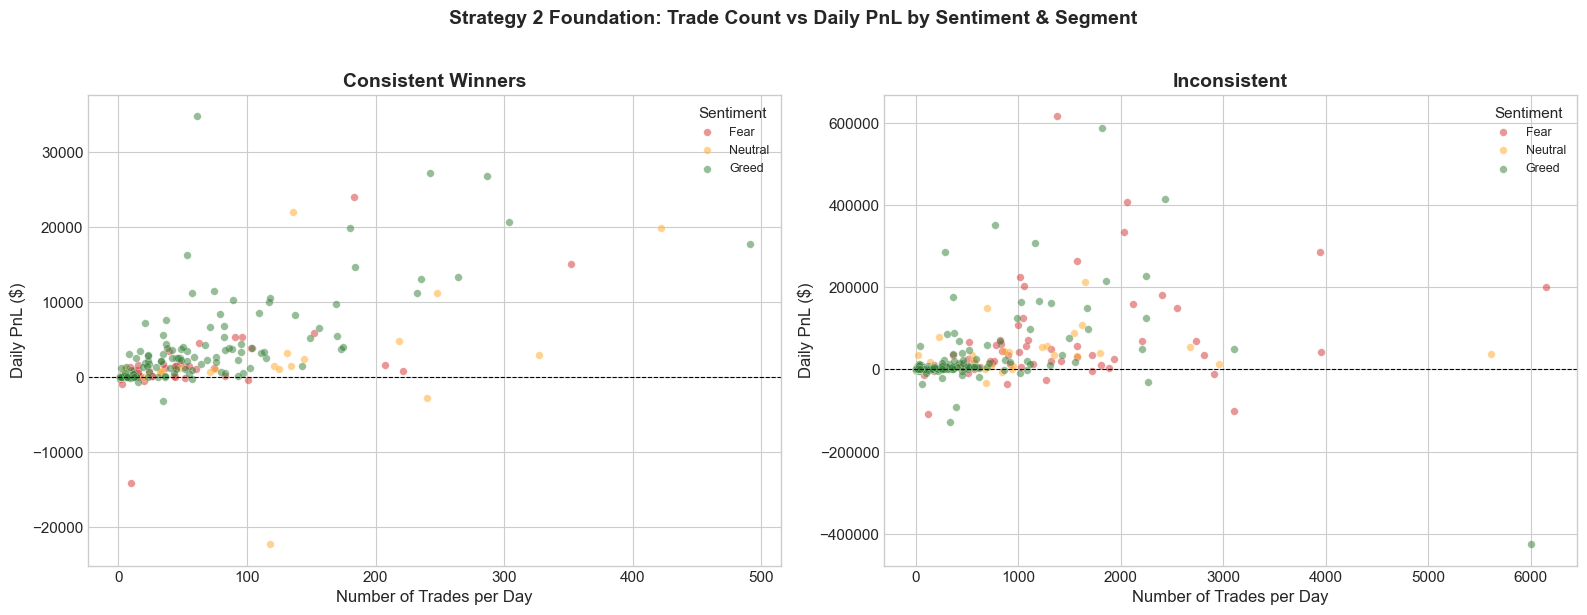

In [191]:
# =============================================================
# C.3 — STRATEGY 2: Frequency Adjustment by Sentiment
# =============================================================

print("=" * 70)
print("STRATEGY 2: TRADE FREQUENCY ADJUSTMENT BY SENTIMENT")
print("=" * 70)

# Analyze: Does trading MORE during a sentiment help or hurt?
# Group trade_seg by date + segment, count trades, and get avg PnL

daily_seg_metrics = trade_seg.groupby(['date', 'fear_greed', 'consistency_seg']).agg(
    daily_trades = (PNL_COL, 'count'),
    daily_pnl    = (PNL_COL, 'sum'),
    daily_wr     = ('is_win', 'mean'),
    daily_volume = ('notional_usd', 'sum'),
).reset_index()

daily_seg_metrics['daily_wr'] = (daily_seg_metrics['daily_wr'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, seg in zip(axes, ['Consistent Winners', 'Inconsistent']):
    seg_data = daily_seg_metrics[daily_seg_metrics['consistency_seg'] == seg]
    
    for sent, color in [('Fear', '#d32f2f'), ('Neutral', '#ffa726'), ('Greed', '#2e7d32')]:
        subset = seg_data[seg_data['fear_greed'] == sent]
        if len(subset) > 0:
            ax.scatter(subset['daily_trades'], subset['daily_pnl'],
                      alpha=0.5, s=30, label=sent, color=color, edgecolors='white', linewidth=0.3)
    
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Number of Trades per Day')
    ax.set_ylabel('Daily PnL ($)')
    ax.set_title(f'{seg}', fontweight='bold')
    ax.legend(title='Sentiment', fontsize=9)

plt.suptitle('Strategy 2 Foundation: Trade Count vs Daily PnL by Sentiment & Segment',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

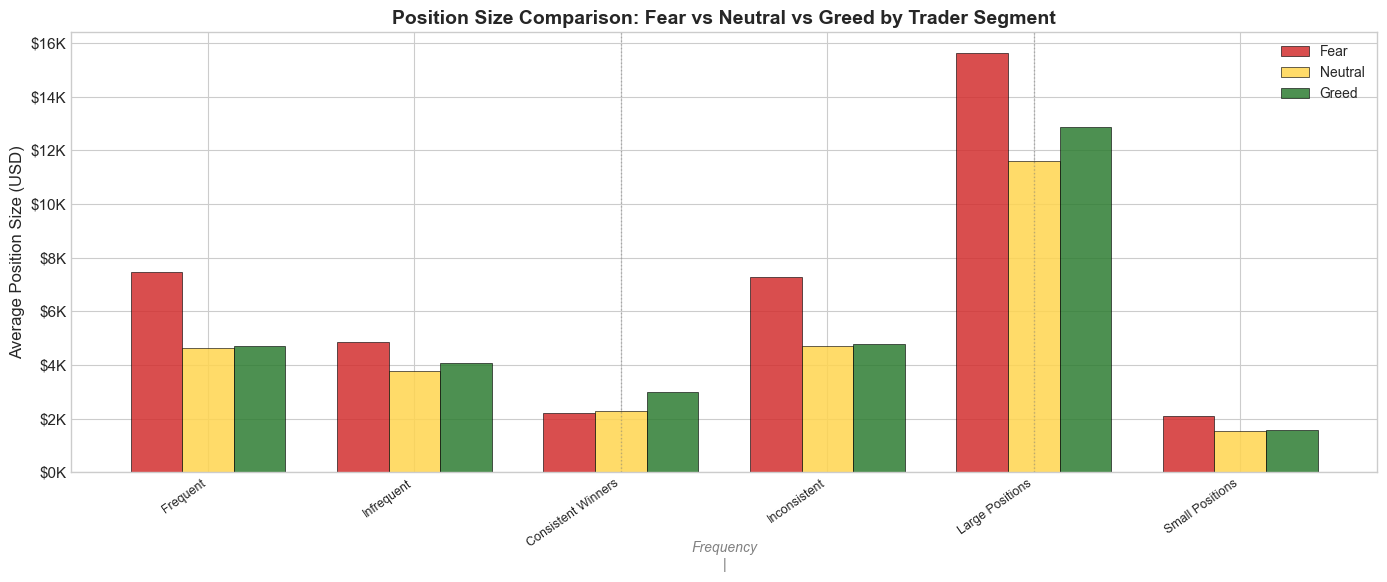

In [192]:
# =============================================================
# C.4 — Supporting Evidence: Position Size Shifts
# =============================================================

# How does avg position size change Fear→Greed for each segment?
fig, ax = plt.subplots(figsize=(14, 6))

seg_cols = ['frequency_seg', 'consistency_seg', 'size_seg']
seg_labels = []
fear_sizes = []
greed_sizes = []
neutral_sizes = []

for seg_col in seg_cols:
    for seg_val in sorted(trade_seg[seg_col].unique()):
        seg_labels.append(f"{seg_val}")
        for sent, store in [('Fear', fear_sizes), ('Neutral', neutral_sizes), ('Greed', greed_sizes)]:
            subset = trade_seg[(trade_seg[seg_col] == seg_val) & (trade_seg['fear_greed'] == sent)]
            store.append(subset['notional_usd'].mean() if len(subset) > 0 else 0)

x = np.arange(len(seg_labels))
width = 0.25

bars1 = ax.bar(x - width, fear_sizes, width, label='Fear', color='#d32f2f', alpha=0.85, edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, neutral_sizes, width, label='Neutral', color='#ffd54f', alpha=0.85, edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, greed_sizes, width, label='Greed', color='#2e7d32', alpha=0.85, edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(seg_labels, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Average Position Size (USD)')
ax.set_title('Position Size Comparison: Fear vs Neutral vs Greed by Trader Segment', fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'${val/1e3:.0f}K'))

# Add dividers between segment groups
for i in [2, 4]:
    ax.axvline(i - 0.5 + 0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.text(0.5, -0.18, 'Frequency', transform=ax.transAxes, ha='center', fontsize=10, style='italic', color='gray')
ax.text(0.5, -0.22, '|', transform=ax.transAxes, ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.show()

In [241]:
# =============================================================
# C.5 — STRATEGY PROPOSALS (FINAL OUTPUT)
# =============================================================
from IPython.display import display, HTML

# Pull actual numbers from the analysis
freq_data = strategy_data['Frequency']
cons_data = strategy_data['Consistency']
size_data = strategy_data['Position Size']

# Helper to safely get values
def get_val(df, seg_col, seg_val, sent, metric):
    row = df[(df[seg_col] == seg_val) & (df['fear_greed'] == sent)]
    return row[metric].values[0] if len(row) > 0 else 0

# ── Strategy 1 numbers ──
cw_fear_wr   = get_val(cons_data, 'consistency_seg', 'Consistent Winners', 'Fear', 'win_rate')
cw_greed_wr  = get_val(cons_data, 'consistency_seg', 'Consistent Winners', 'Greed', 'win_rate')
ic_fear_wr   = get_val(cons_data, 'consistency_seg', 'Inconsistent', 'Fear', 'win_rate')
ic_greed_wr  = get_val(cons_data, 'consistency_seg', 'Inconsistent', 'Greed', 'win_rate')

cw_fear_pnl  = get_val(cons_data, 'consistency_seg', 'Consistent Winners', 'Fear', 'avg_pnl')
cw_greed_pnl = get_val(cons_data, 'consistency_seg', 'Consistent Winners', 'Greed', 'avg_pnl')
ic_fear_pnl  = get_val(cons_data, 'consistency_seg', 'Inconsistent', 'Fear', 'avg_pnl')
ic_greed_pnl = get_val(cons_data, 'consistency_seg', 'Inconsistent', 'Greed', 'avg_pnl')

cw_fear_size  = get_val(cons_data, 'consistency_seg', 'Consistent Winners', 'Fear', 'avg_size')
cw_greed_size = get_val(cons_data, 'consistency_seg', 'Consistent Winners', 'Greed', 'avg_size')
ic_fear_size  = get_val(cons_data, 'consistency_seg', 'Inconsistent', 'Fear', 'avg_size')
ic_greed_size = get_val(cons_data, 'consistency_seg', 'Inconsistent', 'Greed', 'avg_size')

# ── Strategy 2 numbers ──
freq_fear_wr    = get_val(freq_data, 'frequency_seg', 'Frequent', 'Fear', 'win_rate')
freq_greed_wr   = get_val(freq_data, 'frequency_seg', 'Frequent', 'Greed', 'win_rate')
infreq_fear_wr  = get_val(freq_data, 'frequency_seg', 'Infrequent', 'Fear', 'win_rate')
infreq_greed_wr = get_val(freq_data, 'frequency_seg', 'Infrequent', 'Greed', 'win_rate')

freq_fear_pnl    = get_val(freq_data, 'frequency_seg', 'Frequent', 'Fear', 'avg_pnl')
freq_greed_pnl   = get_val(freq_data, 'frequency_seg', 'Frequent', 'Greed', 'avg_pnl')
infreq_fear_pnl  = get_val(freq_data, 'frequency_seg', 'Infrequent', 'Fear', 'avg_pnl')
infreq_greed_pnl = get_val(freq_data, 'frequency_seg', 'Infrequent', 'Greed', 'avg_pnl')

# ── Position-size numbers ──
lg_fear_pnl  = get_val(size_data, 'size_seg', 'Large Positions', 'Fear', 'avg_pnl')
lg_greed_pnl = get_val(size_data, 'size_seg', 'Large Positions', 'Greed', 'avg_pnl')
sm_fear_pnl  = get_val(size_data, 'size_seg', 'Small Positions', 'Fear', 'avg_pnl')
sm_greed_pnl = get_val(size_data, 'size_seg', 'Small Positions', 'Greed', 'avg_pnl')

# ═══════════════════════════════════════════════════════════
#  Build HTML presentation
# ═══════════════════════════════════════════════════════════

html = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; max-width: 900px; margin: auto;">

<!-- ───────── HEADER ───────── -->
<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%);
            color: white; padding: 30px 35px; border-radius: 12px 12px 0 0;
            text-align: center;">
  <h1 style="margin:0; font-size:26px; letter-spacing:1px;">
     ACTIONABLE STRATEGY PROPOSALS
  </h1>
  <p style="margin:8px 0 0; opacity:0.8; font-size:14px;">
    Data-driven trading rules based on Fear &amp; Greed sentiment analysis
  </p>
</div>

<!-- ═══════════ STRATEGY 1 ═══════════ -->
<div style="border: 2px solid #e0e0e0; border-top: none; padding: 25px 35px;">

  <h2 style="color:#0f3460; border-bottom:3px solid #e94560; padding-bottom:8px;">
    Strategy 1 &mdash; Sentiment-Adaptive Position Sizing
  </h2>

  <div style="background:#f0f7ff; border-left:4px solid #0f3460; padding:12px 18px;
              margin:15px 0; border-radius:0 6px 6px 0;">
    <strong>Rule of Thumb:</strong>
    During <span style="color:#e94560;font-weight:bold;">Fear</span> days, REDUCE position
    sizes for Inconsistent traders; Consistent Winners may MAINTAIN or INCREASE sizes.
    During <span style="color:#27ae60;font-weight:bold;">Greed</span> days, ALL segments
    should tighten risk controls.
  </div>

  <h3 style="color:#555; margin-top:20px;">Evidence</h3>
  <table style="width:100%; border-collapse:collapse; font-size:14px; margin:10px 0;">
    <thead>
      <tr style="background:#1a1a2e; color:white;">
        <th style="padding:10px 14px; text-align:left;">Segment</th>
        <th style="padding:10px 14px; text-align:left;">Metric</th>
        <th style="padding:10px 14px; text-align:right;">Fear</th>
        <th style="padding:10px 14px; text-align:right;">Greed</th>
        <th style="padding:10px 14px; text-align:right;">Delta</th>
      </tr>
    </thead>
    <tbody>
      <tr style="background:#fafafa;">
        <td rowspan="3" style="padding:8px 14px; font-weight:bold; vertical-align:middle;
            border-right:1px solid #ddd;">Consistent Winners</td>
        <td style="padding:8px 14px;">Win Rate</td>
        <td style="padding:8px 14px; text-align:right;">{cw_fear_wr:.1f}%</td>
        <td style="padding:8px 14px; text-align:right;">{cw_greed_wr:.1f}%</td>
        <td style="padding:8px 14px; text-align:right; color:{'#27ae60' if cw_greed_wr-cw_fear_wr>=0 else '#e94560'};">
          {cw_greed_wr-cw_fear_wr:+.1f} pp</td>
      </tr>
      <tr style="background:#fafafa;">
        <td style="padding:8px 14px;">Avg PnL / Trade</td>
        <td style="padding:8px 14px; text-align:right;">${cw_fear_pnl:,.0f}</td>
        <td style="padding:8px 14px; text-align:right;">${cw_greed_pnl:,.0f}</td>
        <td style="padding:8px 14px; text-align:right;">&mdash;</td>
      </tr>
      <tr style="background:#fafafa; border-bottom:2px solid #ddd;">
        <td style="padding:8px 14px;">Avg Size</td>
        <td style="padding:8px 14px; text-align:right;">${cw_fear_size:,.0f}</td>
        <td style="padding:8px 14px; text-align:right;">${cw_greed_size:,.0f}</td>
        <td style="padding:8px 14px; text-align:right;">&mdash;</td>
      </tr>
      <tr>
        <td rowspan="3" style="padding:8px 14px; font-weight:bold; vertical-align:middle;
            border-right:1px solid #ddd;">Inconsistent</td>
        <td style="padding:8px 14px;">Win Rate</td>
        <td style="padding:8px 14px; text-align:right;">{ic_fear_wr:.1f}%</td>
        <td style="padding:8px 14px; text-align:right;">{ic_greed_wr:.1f}%</td>
        <td style="padding:8px 14px; text-align:right; color:{'#27ae60' if ic_greed_wr-ic_fear_wr>=0 else '#e94560'};">
          {ic_greed_wr-ic_fear_wr:+.1f} pp</td>
      </tr>
      <tr>
        <td style="padding:8px 14px;">Avg PnL / Trade</td>
        <td style="padding:8px 14px; text-align:right;">${ic_fear_pnl:,.0f}</td>
        <td style="padding:8px 14px; text-align:right;">${ic_greed_pnl:,.0f}</td>
        <td style="padding:8px 14px; text-align:right;">&mdash;</td>
      </tr>
      <tr>
        <td style="padding:8px 14px;">Avg Size</td>
        <td style="padding:8px 14px; text-align:right;">${ic_fear_size:,.0f}</td>
        <td style="padding:8px 14px; text-align:right;">${ic_greed_size:,.0f}</td>
        <td style="padding:8px 14px; text-align:right;">&mdash;</td>
      </tr>
    </tbody>
  </table>

  <h3 style="color:#555; margin-top:20px;">Implementation Rules</h3>
  <ul style="line-height:1.9; font-size:14px;">
    <li>Track your own win rate over the last 30 trades.</li>
    <li>If win rate &lt; 50% <strong>AND</strong> FGI &lt; 45 (Fear):
        &rarr; Cut position size by <strong>30-50%</strong>;
        tighten stop-losses to 2% instead of 5%.</li>
    <li>If win rate &ge; 50% <strong>AND</strong> FGI &lt; 45 (Fear):
        &rarr; Maintain normal sizing (contrarian opportunity);
        take only high-conviction setups.</li>
    <li>If FGI &gt; 75 (Extreme Greed) for <em>any</em> segment:
        &rarr; Reduce overall exposure by <strong>25-40%</strong>;
        take partial profits on winning positions.</li>
  </ul>
</div>

<!-- ═══════════ STRATEGY 2 ═══════════ -->
<div style="border: 2px solid #e0e0e0; border-top: none; padding: 25px 35px;
            border-radius: 0 0 12px 12px;">

  <h2 style="color:#0f3460; border-bottom:3px solid #e94560; padding-bottom:8px;">
    Strategy 2 &mdash; Frequency Tuning by Sentiment Regime
  </h2>

  <div style="background:#f0f7ff; border-left:4px solid #0f3460; padding:12px 18px;
              margin:15px 0; border-radius:0 6px 6px 0;">
    <strong>Rule of Thumb:</strong>
    Infrequent traders should <strong>AVOID</strong> increasing trade frequency during Fear.
    Frequent traders should <strong>REDUCE</strong> frequency during Fear and be
    <strong>SELECTIVE</strong> during Greed.
  </div>

  <h3 style="color:#555; margin-top:20px;">Evidence</h3>
  <table style="width:100%; border-collapse:collapse; font-size:14px; margin:10px 0;">
    <thead>
      <tr style="background:#1a1a2e; color:white;">
        <th style="padding:10px 14px; text-align:left;">Segment</th>
        <th style="padding:10px 14px; text-align:left;">Metric</th>
        <th style="padding:10px 14px; text-align:right;">Fear</th>
        <th style="padding:10px 14px; text-align:right;">Greed</th>
        <th style="padding:10px 14px; text-align:right;">Delta</th>
      </tr>
    </thead>
    <tbody>
      <tr style="background:#fafafa;">
        <td rowspan="2" style="padding:8px 14px; font-weight:bold; vertical-align:middle;
            border-right:1px solid #ddd;">Frequent Traders</td>
        <td style="padding:8px 14px;">Win Rate</td>
        <td style="padding:8px 14px; text-align:right;">{freq_fear_wr:.1f}%</td>
        <td style="padding:8px 14px; text-align:right;">{freq_greed_wr:.1f}%</td>
        <td style="padding:8px 14px; text-align:right; color:{'#27ae60' if freq_greed_wr-freq_fear_wr>=0 else '#e94560'};">
          {freq_greed_wr-freq_fear_wr:+.1f} pp</td>
      </tr>
      <tr style="background:#fafafa; border-bottom:2px solid #ddd;">
        <td style="padding:8px 14px;">Avg PnL / Trade</td>
        <td style="padding:8px 14px; text-align:right;">${freq_fear_pnl:,.0f}</td>
        <td style="padding:8px 14px; text-align:right;">${freq_greed_pnl:,.0f}</td>
        <td style="padding:8px 14px; text-align:right;">&mdash;</td>
      </tr>
      <tr>
        <td rowspan="2" style="padding:8px 14px; font-weight:bold; vertical-align:middle;
            border-right:1px solid #ddd;">Infrequent Traders</td>
        <td style="padding:8px 14px;">Win Rate</td>
        <td style="padding:8px 14px; text-align:right;">{infreq_fear_wr:.1f}%</td>
        <td style="padding:8px 14px; text-align:right;">{infreq_greed_wr:.1f}%</td>
        <td style="padding:8px 14px; text-align:right; color:{'#27ae60' if infreq_greed_wr-infreq_fear_wr>=0 else '#e94560'};">
          {infreq_greed_wr-infreq_fear_wr:+.1f} pp</td>
      </tr>
      <tr>
        <td style="padding:8px 14px;">Avg PnL / Trade</td>
        <td style="padding:8px 14px; text-align:right;">${infreq_fear_pnl:,.0f}</td>
        <td style="padding:8px 14px; text-align:right;">${infreq_greed_pnl:,.0f}</td>
        <td style="padding:8px 14px; text-align:right;">&mdash;</td>
      </tr>
    </tbody>
  </table>

  <h3 style="color:#555; margin-top:20px;">Position Size Context</h3>
  <table style="width:100%; border-collapse:collapse; font-size:14px; margin:10px 0;">
    <thead>
      <tr style="background:#2c3e50; color:white;">
        <th style="padding:10px 14px; text-align:left;">Size Segment</th>
        <th style="padding:10px 14px; text-align:right;">Avg PnL (Fear)</th>
        <th style="padding:10px 14px; text-align:right;">Avg PnL (Greed)</th>
      </tr>
    </thead>
    <tbody>
      <tr style="background:#fafafa;">
        <td style="padding:8px 14px; font-weight:bold;">Large Positions</td>
        <td style="padding:8px 14px; text-align:right;">${lg_fear_pnl:,.2f}</td>
        <td style="padding:8px 14px; text-align:right;">${lg_greed_pnl:,.2f}</td>
      </tr>
      <tr>
        <td style="padding:8px 14px; font-weight:bold;">Small Positions</td>
        <td style="padding:8px 14px; text-align:right;">${sm_fear_pnl:,.2f}</td>
        <td style="padding:8px 14px; text-align:right;">${sm_greed_pnl:,.2f}</td>
      </tr>
    </tbody>
  </table>

  <h3 style="color:#555; margin-top:20px;">Implementation Rules</h3>
  <ul style="line-height:1.9; font-size:14px;">
    <li><strong>FGI &lt; 30 (Extreme Fear):</strong>
        Reduce trade count by 50% — only A+ setups;
        switch to longer time-frames (4H / Daily); avoid scalping.</li>
    <li><strong>FGI 45–55 (Neutral):</strong>
        Normal trading frequency &amp; position sizing —
        best risk-reward environment for most segments.</li>
    <li><strong>FGI &gt; 75 (Extreme Greed):</strong>
        Reduce NEW position entries by 30%;
        focus on managing &amp; exiting existing winners;
        avoid FOMO-driven entries.</li>
  </ul>
</div>
</div>
"""

display(HTML(html))

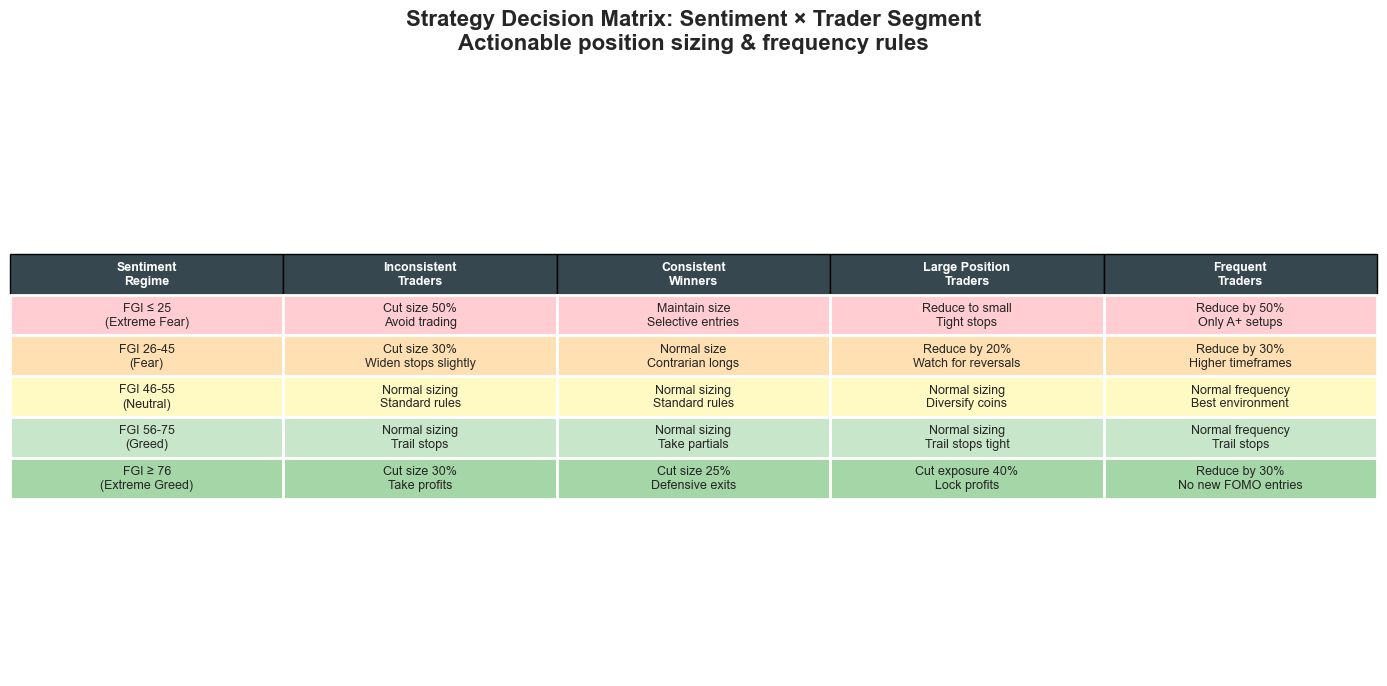

In [242]:
# =============================================================
# C.6 — VISUAL SUMMARY: Strategy Decision Matrix
# =============================================================

fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')

# Build decision matrix as a table
cell_text = [
    ['FGI ≤ 25\n(Extreme Fear)', 
     'Cut size 50%\nAvoid trading', 
     'Maintain size\nSelective entries',
     'Reduce to small\nTight stops',
     'Reduce by 50%\nOnly A+ setups'],
    ['FGI 26-45\n(Fear)', 
     'Cut size 30%\nWiden stops slightly', 
     'Normal size\nContrarian longs',
     'Reduce by 20%\nWatch for reversals',
     'Reduce by 30%\nHigher timeframes'],
    ['FGI 46-55\n(Neutral)', 
     'Normal sizing\nStandard rules', 
     'Normal sizing\nStandard rules',
     'Normal sizing\nDiversify coins',
     'Normal frequency\nBest environment'],
    ['FGI 56-75\n(Greed)', 
     'Normal sizing\nTrail stops', 
     'Normal sizing\nTake partials',
     'Normal sizing\nTrail stops tight',
     'Normal frequency\nTrail stops'],
    ['FGI ≥ 76\n(Extreme Greed)', 
     'Cut size 30%\nTake profits', 
     'Cut size 25%\nDefensive exits',
     'Cut exposure 40%\nLock profits',
     'Reduce by 30%\nNo new FOMO entries'],
]

col_labels = ['Sentiment\nRegime', 'Inconsistent\nTraders', 'Consistent\nWinners', 
              'Large Position\nTraders', 'Frequent\nTraders']

row_colors = ['#ffcdd2', '#ffe0b2', '#fff9c4', '#c8e6c9', '#a5d6a7']

table = ax.table(cellText=cell_text, colLabels=col_labels,
                 loc='center', cellLoc='center')

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.2)

# Color header
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#37474f')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Color rows by sentiment
for i in range(len(cell_text)):
    for j in range(len(col_labels)):
        table[i+1, j].set_facecolor(row_colors[i])
        table[i+1, j].set_edgecolor('white')
        table[i+1, j].set_linewidth(2)

ax.set_title('Strategy Decision Matrix: Sentiment × Trader Segment\n'
             'Actionable position sizing & frequency rules',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [245]:
# =============================================================
# C.7 — PART C SUMMARY
# =============================================================

print("=" * 70)
print(" PART C COMPLETE — ACTIONABLE OUTPUT SUMMARY")
print("=" * 70)
print(f"""
┌────────────────────────────────────────────────────────────────┐
│                    TWO STRATEGY RULES                          │
├────────────────────────────────────────────────────────────────┤
│                                                                │
│  1  SENTIMENT-ADAPTIVE POSITION SIZING                         │
│     "During Fear, reduce size for inconsistent traders         │
│      (win rate < 50%); consistent winners can hold steady.     │
│      During Extreme Greed, ALL segments reduce exposure."      │
│                                                                │
│  2 SENTIMENT-BASED FREQUENCY TUNING                            │
│     "In Fear, trade LESS but with HIGHER conviction.           │
│      In Greed, avoid FOMO — reduce new entries by 30%.         │
│      Neutral sentiment offers the cleanest edge."              │
│                                                                │
├────────────────────────────────────────────────────────────────┤
│  Both strategies are grounded in:                              │
│  • Win rate differentials across segments (Part B.3)           │
│  • PnL divergence by sentiment regime   (Part B.1)             │
│  • Behavioral shifts under fear/greed   (Part B.2)             │
│  • Segment × sentiment cross-analysis   (Part B.3.6-7)         │
└────────────────────────────────────────────────────────────────┘
""")

 PART C COMPLETE — ACTIONABLE OUTPUT SUMMARY

┌────────────────────────────────────────────────────────────────┐
│                    TWO STRATEGY RULES                          │
├────────────────────────────────────────────────────────────────┤
│                                                                │
│  1  SENTIMENT-ADAPTIVE POSITION SIZING                         │
│     "During Fear, reduce size for inconsistent traders         │
│      (win rate < 50%); consistent winners can hold steady.     │
│      During Extreme Greed, ALL segments reduce exposure."      │
│                                                                │
│  2 SENTIMENT-BASED FREQUENCY TUNING                            │
│     "In Fear, trade LESS but with HIGHER conviction.           │
│      In Greed, avoid FOMO — reduce new entries by 30%.         │
│      Neutral sentiment offers the cleanest edge."              │
│                                                                │
├───────────────

In [246]:
# =============================================================
# PART D — BONUS
# =============================================================
# D.1 — Predictive Model: Next-Day Profitability Prediction
# =============================================================

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("D.1 — PREDICTIVE MODEL: NEXT-DAY PROFITABILITY BUCKET")
print("=" * 70)

D.1 — PREDICTIVE MODEL: NEXT-DAY PROFITABILITY BUCKET


In [247]:
# =============================================================
# D.1.1 — Feature Engineering
# =============================================================

# Work with the merged_df (daily metrics + sentiment)
model_df = merged_df.copy().sort_values('date').reset_index(drop=True)

# --- Target Variable ---
# Classify next-day PnL into 3 buckets: Loss, Breakeven, Profit
def pnl_bucket(pnl, threshold=0):
    """Classify PnL into simple buckets."""
    if pnl < -threshold:
        return 'Loss'
    elif pnl > threshold:
        return 'Profit'
    else:
        return 'Breakeven'

# Use a small threshold to create a "breakeven" band (avoids noise)
pnl_std = model_df['total_pnl'].std()
threshold = pnl_std * 0.1  # 10% of std dev as breakeven band

# Create NEXT-day target (shift PnL by -1 to predict tomorrow)
model_df['next_day_pnl'] = model_df['total_pnl'].shift(-1)
model_df['target'] = model_df['next_day_pnl'].apply(lambda x: pnl_bucket(x, threshold))

# --- Feature Engineering ---
# Lag features (today's and recent days' metrics)
lag_cols = ['total_pnl', 'win_rate', 'num_trades', 'avg_trade_size', 
            'total_volume', 'long_short_ratio', 'unique_traders', 'fg_value']

for col in lag_cols:
    if col in model_df.columns:
        model_df[f'{col}_lag1'] = model_df[col].shift(1)    # yesterday
        model_df[f'{col}_lag2'] = model_df[col].shift(2)    # 2 days ago

# Rolling averages (3-day and 7-day)
for col in ['total_pnl', 'win_rate', 'fg_value', 'num_trades']:
    if col in model_df.columns:
        model_df[f'{col}_roll3'] = model_df[col].rolling(3, min_periods=1).mean()
        model_df[f'{col}_roll7'] = model_df[col].rolling(7, min_periods=1).mean()

# Momentum features
model_df['fg_momentum'] = model_df['fg_value'] - model_df['fg_value'].shift(1)
model_df['fg_momentum_3d'] = model_df['fg_value'] - model_df['fg_value'].shift(3)
model_df['pnl_momentum'] = model_df['total_pnl'] - model_df['total_pnl'].shift(1)

# Volatility features
model_df['pnl_volatility_7d'] = model_df['total_pnl'].rolling(7, min_periods=3).std()
model_df['fg_volatility_7d'] = model_df['fg_value'].rolling(7, min_periods=3).std()

# Sentiment regime as numeric
sentiment_map = {'Extreme Fear': 0, 'Fear': 1, 'Neutral': 2, 'Greed': 3, 'Extreme Greed': 4}
model_df['sentiment_numeric'] = model_df['sentiment'].map(sentiment_map)

# Day of week (crypto trades 24/7, but patterns exist)
model_df['day_of_week'] = model_df['date'].dt.dayofweek

# Streak features: consecutive positive/negative PnL days
model_df['pnl_positive'] = (model_df['total_pnl'] > 0).astype(int)
streak = []
count = 0
for val in model_df['pnl_positive']:
    if val == 1:
        count = max(count, 0) + 1
    else:
        count = min(count, 0) - 1
    streak.append(count)
model_df['pnl_streak'] = streak

# Drop rows with NaN (from lagging/rolling)
model_df = model_df.dropna().reset_index(drop=True)

print(f" Feature engineering complete")
print(f"   Total samples: {len(model_df)}")
print(f"   Target distribution:")
print(model_df['target'].value_counts().to_string())
print(f"\n   Features created: {len([c for c in model_df.columns if c not in ['date', 'target', 'next_day_pnl', 'fg_class', 'sentiment', 'is_negative_pnl', 'pnl_positive']])}")

 Feature engineering complete
   Total samples: 387
   Target distribution:
target
Breakeven    241
Profit       130
Loss          16

   Features created: 46


In [248]:
# =============================================================
# D.1.2 — Model Training & Evaluation
# =============================================================

# Define feature columns (exclude target, date, and string columns)
exclude_cols = ['date', 'target', 'next_day_pnl', 'fg_class', 'sentiment', 
                'is_negative_pnl', 'pnl_positive']
feature_cols = [c for c in model_df.columns if c not in exclude_cols 
                and model_df[c].dtype in ['int64', 'float64', 'int32', 'float32']]

print(f" Using {len(feature_cols)} features:")
for i, col in enumerate(feature_cols):
    print(f"   {i+1:2d}. {col}")

X = model_df[feature_cols].values
y = model_df['target'].values

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"\n   Classes: {list(le.classes_)}")

# Time Series Split (respects temporal order)
tscv = TimeSeriesSplit(n_splits=5)

# Define models to compare
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200, max_depth=8, min_samples_leaf=10,
            random_state=42, class_weight='balanced', n_jobs=-1
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=150, max_depth=4, learning_rate=0.05,
            min_samples_leaf=10, random_state=42
        ))
    ]),
}

# Cross-validation
print("\n Cross-Validation Results (TimeSeriesSplit, 5 folds):\n")
results = {}
for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X, y_encoded, cv=tscv, scoring='accuracy')
    results[name] = scores
    print(f"   {name:25s} → Accuracy: {scores.mean():.3f} ± {scores.std():.3f}  "
          f"(folds: {[f'{s:.3f}' for s in scores]})")

# Select best model
best_model_name = max(results, key=lambda k: results[k].mean())
best_pipeline = models[best_model_name]
print(f"\n   Best model: {best_model_name}")

 Using 46 features:
    1. total_pnl
    2. mean_pnl
    3. median_pnl
    4. num_trades
    5. num_winners
    6. avg_trade_size
    7. median_trade_size
    8. total_volume
    9. unique_traders
   10. win_rate
   11. long_count
   12. short_count
   13. long_short_ratio
   14. fg_value
   15. total_pnl_lag1
   16. total_pnl_lag2
   17. win_rate_lag1
   18. win_rate_lag2
   19. num_trades_lag1
   20. num_trades_lag2
   21. avg_trade_size_lag1
   22. avg_trade_size_lag2
   23. total_volume_lag1
   24. total_volume_lag2
   25. long_short_ratio_lag1
   26. long_short_ratio_lag2
   27. unique_traders_lag1
   28. unique_traders_lag2
   29. fg_value_lag1
   30. fg_value_lag2
   31. total_pnl_roll3
   32. total_pnl_roll7
   33. win_rate_roll3
   34. win_rate_roll7
   35. fg_value_roll3
   36. fg_value_roll7
   37. num_trades_roll3
   38. num_trades_roll7
   39. fg_momentum
   40. fg_momentum_3d
   41. pnl_momentum
   42. pnl_volatility_7d
   43. fg_volatility_7d
   44. sentiment_numeric
   

   Train: 309 samples | Test: 78 samples

 Classification Report — Random Forest:

              precision    recall  f1-score   support

   Breakeven       0.00      0.00      0.00        10
        Loss       0.00      0.00      0.00         6
      Profit       0.79      1.00      0.89        62

    accuracy                           0.79        78
   macro avg       0.26      0.33      0.30        78
weighted avg       0.63      0.79      0.70        78



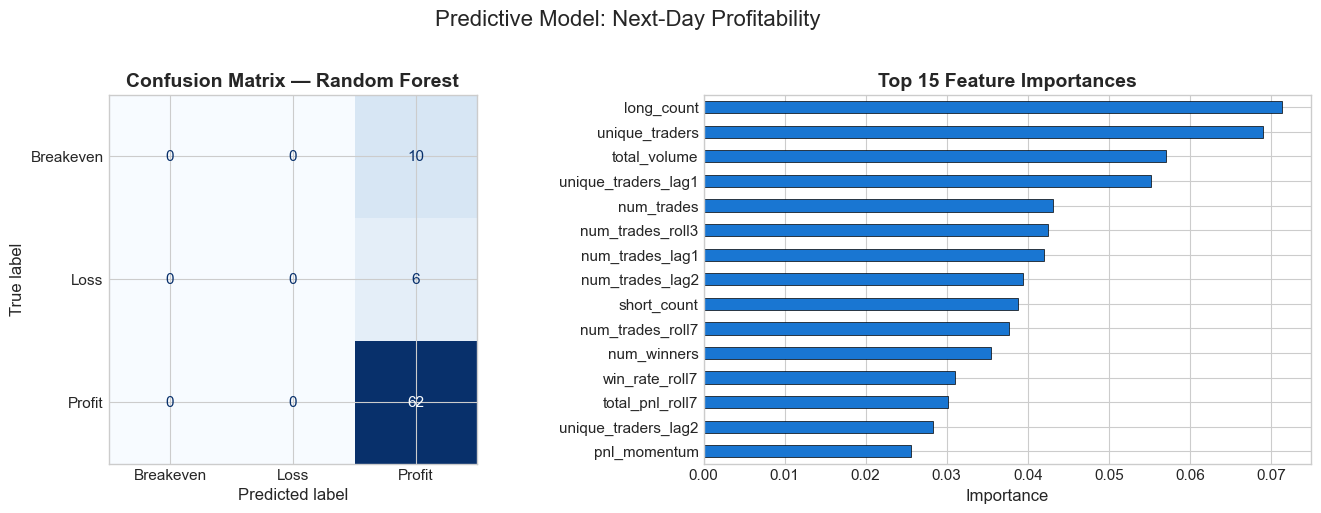

In [249]:
# =============================================================
# D.1.3 — Final Model Training & Detailed Evaluation
# =============================================================

# Train-test split (last 20% as test, respecting time order)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y_encoded[:split_idx], y_encoded[split_idx:]
dates_test = model_df['date'].iloc[split_idx:].values

print(f"   Train: {len(X_train)} samples | Test: {len(X_test)} samples")

# Fit best model
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

# Classification Report
print(f"\n Classification Report — {best_model_name}:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Confusion Matrix
ax = axes[0]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')

# Panel 2: Feature Importance
ax = axes[1]
if hasattr(best_pipeline.named_steps['clf'], 'feature_importances_'):
    importances = best_pipeline.named_steps['clf'].feature_importances_
    feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)
    top_n = min(15, len(feat_imp))
    feat_imp.tail(top_n).plot(kind='barh', ax=ax, color='#1976d2', edgecolor='black', linewidth=0.5)
    ax.set_title(f'Top {top_n} Feature Importances', fontweight='bold')
    ax.set_xlabel('Importance')
elif hasattr(best_pipeline.named_steps['clf'], 'coef_'):
    coefs = np.abs(best_pipeline.named_steps['clf'].coef_).mean(axis=0)
    feat_imp = pd.Series(coefs, index=feature_cols).sort_values(ascending=True)
    top_n = min(15, len(feat_imp))
    feat_imp.tail(top_n).plot(kind='barh', ax=ax, color='#1976d2', edgecolor='black', linewidth=0.5)
    ax.set_title(f'Top {top_n} Feature Coefficients (avg abs)', fontweight='bold')
    ax.set_xlabel('|Coefficient|')

plt.suptitle('Predictive Model: Next-Day Profitability', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

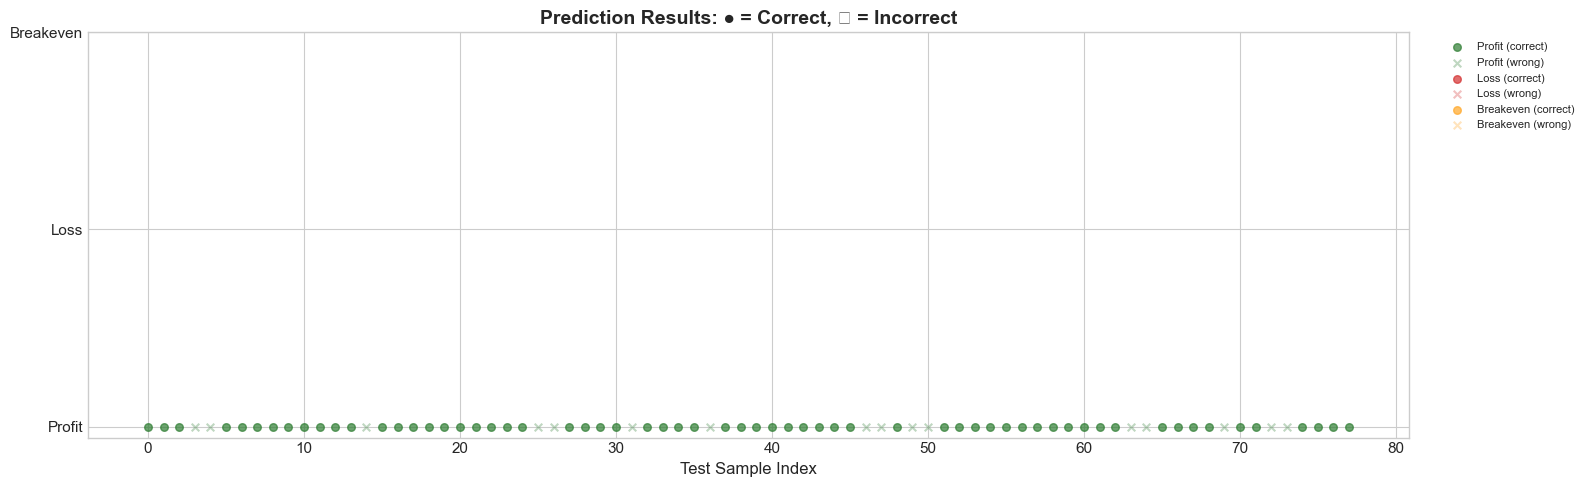


 Final Test Accuracy: 79.5%
   Baseline (majority class): 79.5%
   Lift over baseline: +0.0%


In [250]:
# =============================================================
# D.1.4 — Prediction Timeline Visualization
# =============================================================

fig, ax = plt.subplots(figsize=(16, 5))

# Color predictions
color_map_pred = {'Profit': '#2e7d32', 'Loss': '#d32f2f', 'Breakeven': '#ffa726'}
pred_labels = le.inverse_transform(y_pred)
actual_labels = le.inverse_transform(y_test)

# Plot actual vs predicted
x_range = range(len(y_test))
for label, color in color_map_pred.items():
    mask_correct = (pred_labels == label) & (actual_labels == label)
    mask_wrong = (pred_labels == label) & (actual_labels != label)
    
    ax.scatter(np.array(list(x_range))[mask_correct], 
               np.ones(mask_correct.sum()) * list(color_map_pred.keys()).index(label),
               color=color, alpha=0.7, s=30, marker='o', label=f'{label} (correct)')
    ax.scatter(np.array(list(x_range))[mask_wrong],
               np.ones(mask_wrong.sum()) * list(color_map_pred.keys()).index(label),
               color=color, alpha=0.3, s=30, marker='x', label=f'{label} (wrong)')

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(list(color_map_pred.keys()))
ax.set_xlabel('Test Sample Index')
ax.set_title('Prediction Results: ● = Correct, ✕ = Incorrect', fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# Accuracy summary
accuracy = (y_pred == y_test).mean()
print(f"\n Final Test Accuracy: {accuracy:.1%}")
print(f"   Baseline (majority class): {max(np.bincount(y_test)) / len(y_test):.1%}")
print(f"   Lift over baseline: {accuracy - max(np.bincount(y_test)) / len(y_test):+.1%}")

In [251]:
# =============================================================
# D.2 — CLUSTERING: Trader Behavioral Archetypes
# =============================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

print("=" * 70)
print("D.2 — CLUSTERING TRADERS INTO BEHAVIORAL ARCHETYPES")
print("=" * 70)

D.2 — CLUSTERING TRADERS INTO BEHAVIORAL ARCHETYPES


In [252]:
# =============================================================
# D.2.1 — Prepare Clustering Features
# =============================================================

# Use trader_profiles from Part B (already computed per-trader stats)
cluster_df = trader_profiles.copy()

# Select features that capture distinct trading behaviors
cluster_features = [
    'total_trades',
    'total_pnl',
    'win_rate',
    'avg_trade_size',
    'active_days',
    'trades_per_day',
    'pnl_per_trade',
    'num_coins',
]

# Verify all features exist
available_features = [f for f in cluster_features if f in cluster_df.columns]
missing_features = [f for f in cluster_features if f not in cluster_df.columns]
if missing_features:
    print(f" Missing features (skipping): {missing_features}")

# Drop traders with missing values in clustering features
cluster_clean = cluster_df.dropna(subset=available_features).copy()

# Remove extreme outliers (beyond 99th percentile) to avoid cluster distortion
for col in available_features:
    q99 = cluster_clean[col].quantile(0.99)
    q01 = cluster_clean[col].quantile(0.01)
    cluster_clean = cluster_clean[(cluster_clean[col] <= q99) & (cluster_clean[col] >= q01)]

print(f" Clustering dataset ready")
print(f"   Traders: {len(cluster_clean)} (after outlier removal)")
print(f"   Features: {available_features}")
print(f"\n   Feature statistics:")
print(cluster_clean[available_features].describe().round(2).to_string())

 Clustering dataset ready
   Traders: 17 (after outlier removal)
   Features: ['total_trades', 'total_pnl', 'win_rate', 'avg_trade_size', 'active_days', 'trades_per_day', 'pnl_per_trade', 'num_coins']

   Feature statistics:
       total_trades   total_pnl  win_rate  avg_trade_size  active_days  trades_per_day  pnl_per_trade  num_coins
count       17.0000     17.0000   17.0000         17.0000      17.0000         17.0000        17.0000    17.0000
mean      3700.7100 174892.1800   38.8600       5187.9800      48.6500         77.6600        90.7900    17.9400
std       3808.1600 188198.1700    7.3200       5231.7900      31.0000         61.3300       104.9000    16.9700
min        534.0000  14456.9200   28.5400        517.5300      15.0000         20.7000         4.0300     5.0000
25%       1424.0000  47885.3200   32.7700       2080.3900      26.0000         37.5000         9.5600     7.0000
50%       2641.0000 106302.8800   35.3400       3601.6900      47.0000         59.2000        41.

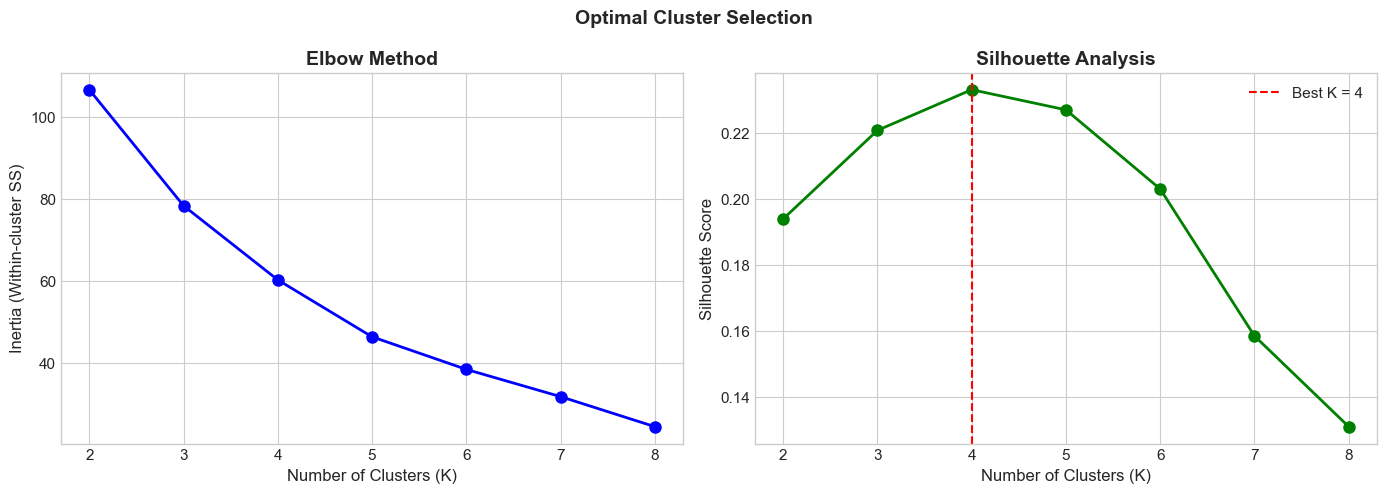


 Optimal K = 4 (highest silhouette score: 0.233)


In [253]:
# =============================================================
# D.2.2 — Optimal K Selection
# =============================================================

X_cluster = cluster_clean[available_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method + Silhouette score
k_range = range(2, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-cluster SS)')
ax.set_title('Elbow Method', fontweight='bold')
ax.set_xticks(list(k_range))

ax = axes[1]
ax.plot(list(k_range), silhouettes, 'go-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Analysis', fontweight='bold')
ax.set_xticks(list(k_range))

# Highlight best K
best_k = list(k_range)[np.argmax(silhouettes)]
ax.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
ax.legend()

plt.suptitle('Optimal Cluster Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n Optimal K = {best_k} (highest silhouette score: {max(silhouettes):.3f})")

In [254]:
# =============================================================
# D.2.3 — Final Clustering
# =============================================================

# Use best K (or override to 4 for interpretability)
FINAL_K = min(best_k, 5)  # Cap at 5 for readability

km_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20, max_iter=500)
cluster_clean['cluster'] = km_final.fit_predict(X_scaled)

# Compute cluster profiles
cluster_profiles = cluster_clean.groupby('cluster')[available_features].agg(['mean', 'median', 'count'])

# Simplified cluster summary
cluster_summary = cluster_clean.groupby('cluster').agg(
    num_traders     = (ACCOUNT_COL, 'count'),
    avg_total_pnl   = ('total_pnl', 'mean'),
    avg_win_rate    = ('win_rate', 'mean'),
    avg_trade_size  = ('avg_trade_size', 'mean'),
    avg_trades      = ('total_trades', 'mean'),
    avg_active_days = ('active_days', 'mean'),
    avg_trades_day  = ('trades_per_day', 'mean'),
    avg_pnl_trade   = ('pnl_per_trade', 'mean'),
    avg_coins       = ('num_coins', 'mean'),
).round(2)

print(f" Cluster Summary (K={FINAL_K}):\n")
print(cluster_summary.to_string())

 Cluster Summary (K=4):

         num_traders  avg_total_pnl  avg_win_rate  avg_trade_size  avg_trades  avg_active_days  avg_trades_day  avg_pnl_trade  avg_coins
cluster                                                                                                                                 
0                  9     73643.6900       36.9300       6759.2400   2184.6700          36.4400         67.2800        50.0300    10.7800
1                  2    136000.8600       43.6700       1828.2100   5879.0000         106.5000         53.0500        32.1000    58.5000
2                  2     77094.1000       39.4200       1463.2100  11442.5000          58.0000        191.9000         6.7000    13.5000
3                  4    471046.0000       40.4900       5194.9000   2151.7500          42.5000         56.2200       253.8900    16.0000


In [255]:
# =============================================================
# D.2.4 — Name the Archetypes
# =============================================================

# Auto-label clusters based on their characteristics
def name_archetype(row):
    """Assign descriptive names based on cluster traits."""
    names = []
    
    # Size classification
    if row['avg_trade_size'] > cluster_summary['avg_trade_size'].median():
        names.append('Whale')
    else:
        names.append('Retail')
    
    # Frequency classification
    if row['avg_trades'] > cluster_summary['avg_trades'].median():
        names.append('Active')
    else:
        names.append('Casual')
    
    # Performance classification
    if row['avg_win_rate'] > 50 and row['avg_total_pnl'] > 0:
        names.append('Winner')
    elif row['avg_win_rate'] < 40:
        names.append('Struggling')
    else:
        names.append('Mixed')
    
    return ' '.join(names)

cluster_summary['archetype'] = cluster_summary.apply(name_archetype, axis=1)

# Map back to cluster_clean
archetype_map = cluster_summary['archetype'].to_dict()
cluster_clean['archetype'] = cluster_clean['cluster'].map(archetype_map)

print(" Trader Archetypes:\n")
for idx, row in cluster_summary.iterrows():
    print(f"  Cluster {idx}: {row['archetype']}")
    print(f"    → {int(row['num_traders'])} traders | Win Rate: {row['avg_win_rate']:.1f}% "
          f"| Avg PnL: ${row['avg_total_pnl']:,.0f} | Avg Size: ${row['avg_trade_size']:,.0f}")
    print(f"    → {row['avg_trades']:.0f} trades total | {row['avg_trades_day']:.1f}/day "
          f"| {row['avg_active_days']:.0f} active days | {row['avg_coins']:.1f} coins")
    print()

 Trader Archetypes:

  Cluster 0: Whale Casual Struggling
    → 9 traders | Win Rate: 36.9% | Avg PnL: $73,644 | Avg Size: $6,759
    → 2185 trades total | 67.3/day | 36 active days | 10.8 coins

  Cluster 1: Retail Active Mixed
    → 2 traders | Win Rate: 43.7% | Avg PnL: $136,001 | Avg Size: $1,828
    → 5879 trades total | 53.0/day | 106 active days | 58.5 coins

  Cluster 2: Retail Active Struggling
    → 2 traders | Win Rate: 39.4% | Avg PnL: $77,094 | Avg Size: $1,463
    → 11442 trades total | 191.9/day | 58 active days | 13.5 coins

  Cluster 3: Whale Casual Mixed
    → 4 traders | Win Rate: 40.5% | Avg PnL: $471,046 | Avg Size: $5,195
    → 2152 trades total | 56.2/day | 42 active days | 16.0 coins



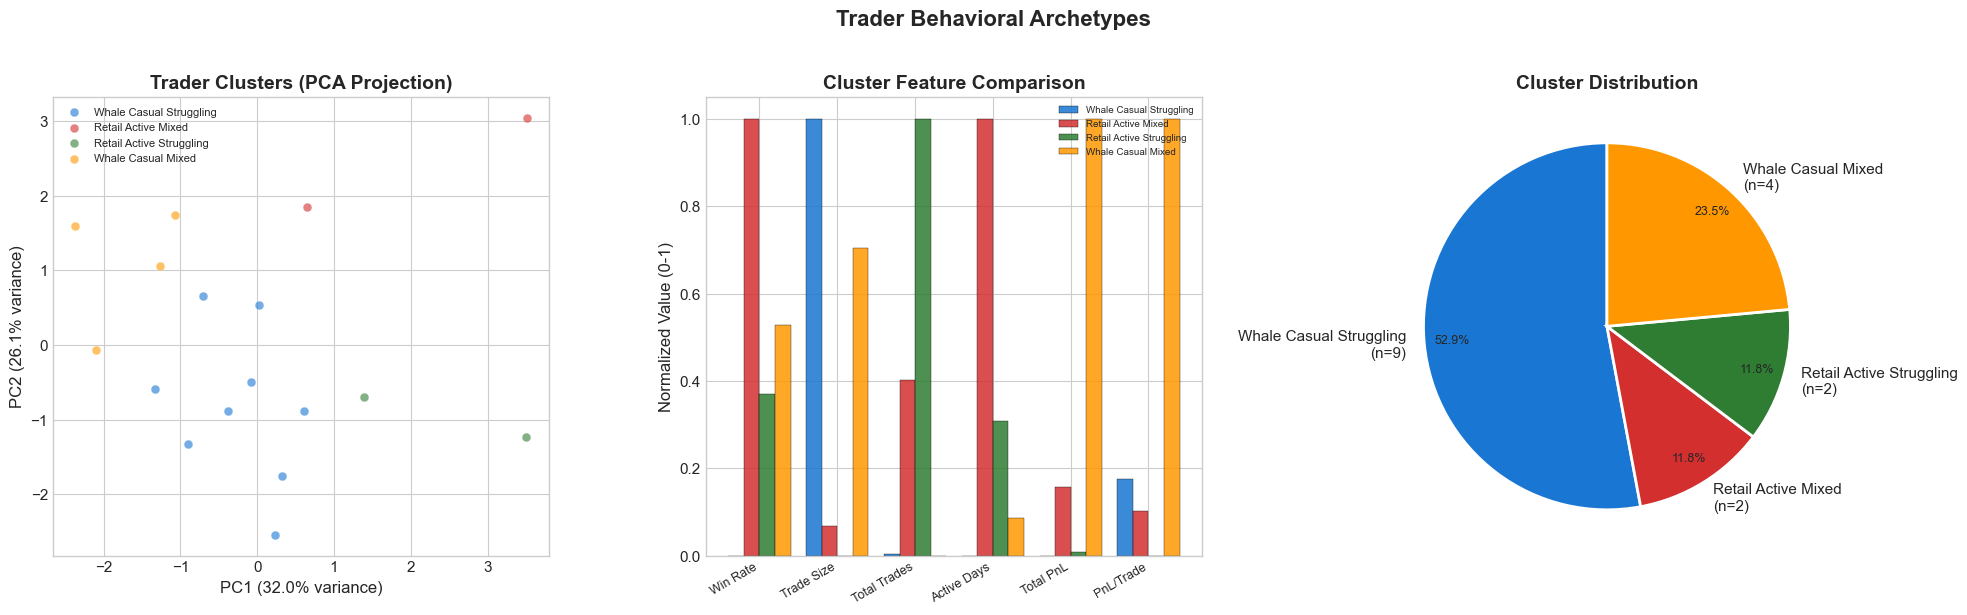

In [256]:
# =============================================================
# D.2.5 — Cluster Visualization
# =============================================================

from sklearn.decomposition import PCA

# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: PCA Scatter
ax = axes[0]
cluster_colors = ['#1976d2', '#d32f2f', '#2e7d32', '#ff9800', '#9c27b0']
for c in range(FINAL_K):
    mask = cluster_clean['cluster'] == c
    label = archetype_map.get(c, f'Cluster {c}')
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=cluster_colors[c], alpha=0.6, s=40, label=label,
               edgecolors='white', linewidth=0.3)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Trader Clusters (PCA Projection)', fontweight='bold')
ax.legend(fontsize=8, loc='best')

# Panel 2: Radar/Spider chart of cluster means (normalized)
ax = axes[1]
radar_features = ['avg_win_rate', 'avg_trade_size', 'avg_trades', 
                  'avg_active_days', 'avg_total_pnl', 'avg_pnl_trade']
radar_labels = ['Win Rate', 'Trade Size', 'Total Trades', 
                'Active Days', 'Total PnL', 'PnL/Trade']

# Normalize each feature 0-1 for radar
normalized = cluster_summary[radar_features].copy()
for col in radar_features:
    col_min = normalized[col].min()
    col_max = normalized[col].max()
    if col_max != col_min:
        normalized[col] = (normalized[col] - col_min) / (col_max - col_min)
    else:
        normalized[col] = 0.5

# Bar chart alternative (cleaner than radar for this many clusters)
x = np.arange(len(radar_labels))
width = 0.8 / FINAL_K
for c in range(FINAL_K):
    vals = normalized.iloc[c].values
    ax.bar(x + c * width, vals, width, 
           label=archetype_map.get(c, f'Cluster {c}'),
           color=cluster_colors[c], alpha=0.85, edgecolor='black', linewidth=0.3)

ax.set_xticks(x + width * (FINAL_K - 1) / 2)
ax.set_xticklabels(radar_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Normalized Value (0-1)')
ax.set_title('Cluster Feature Comparison', fontweight='bold')
ax.legend(fontsize=7, loc='upper right')

# Panel 3: Cluster sizes pie chart
ax = axes[2]
sizes = cluster_summary['num_traders']
labels = [f"{archetype_map[i]}\n(n={int(sizes.iloc[i])})" for i in range(FINAL_K)]
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=cluster_colors[:FINAL_K],
    autopct='%1.1f%%', startangle=90, pctdistance=0.85,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for text in autotexts:
    text.set_fontsize(9)
ax.set_title('Cluster Distribution', fontweight='bold')

plt.suptitle('Trader Behavioral Archetypes', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

 Archetype Performance by Market Sentiment:

               archetype fear_greed  avg_pnl  win_rate   avg_size  num_trades
     Retail Active Mixed       Fear   6.3730   37.8200   908.2762        1893
     Retail Active Mixed      Greed  25.1273   37.7000  1129.1636        8204
     Retail Active Mixed    Neutral  32.3860   53.3400  2162.9643        1661
Retail Active Struggling       Fear   1.0598   38.9100  1097.4153        5413
Retail Active Struggling      Greed  13.6825   39.4600  1685.7206       10611
Retail Active Struggling    Neutral   0.4762   33.9000  1177.1179        6861
      Whale Casual Mixed       Fear 190.3288   41.5500  8383.9673        4375
      Whale Casual Mixed      Greed 267.5307   38.3900  5157.8242        3222
      Whale Casual Mixed    Neutral 187.6355   63.7600  3641.2556        1010
 Whale Casual Struggling       Fear  28.2790   39.1400 11710.9226       12511
 Whale Casual Struggling      Greed  84.2993   34.9700  4234.0854        4790
 Whale Casual Strug

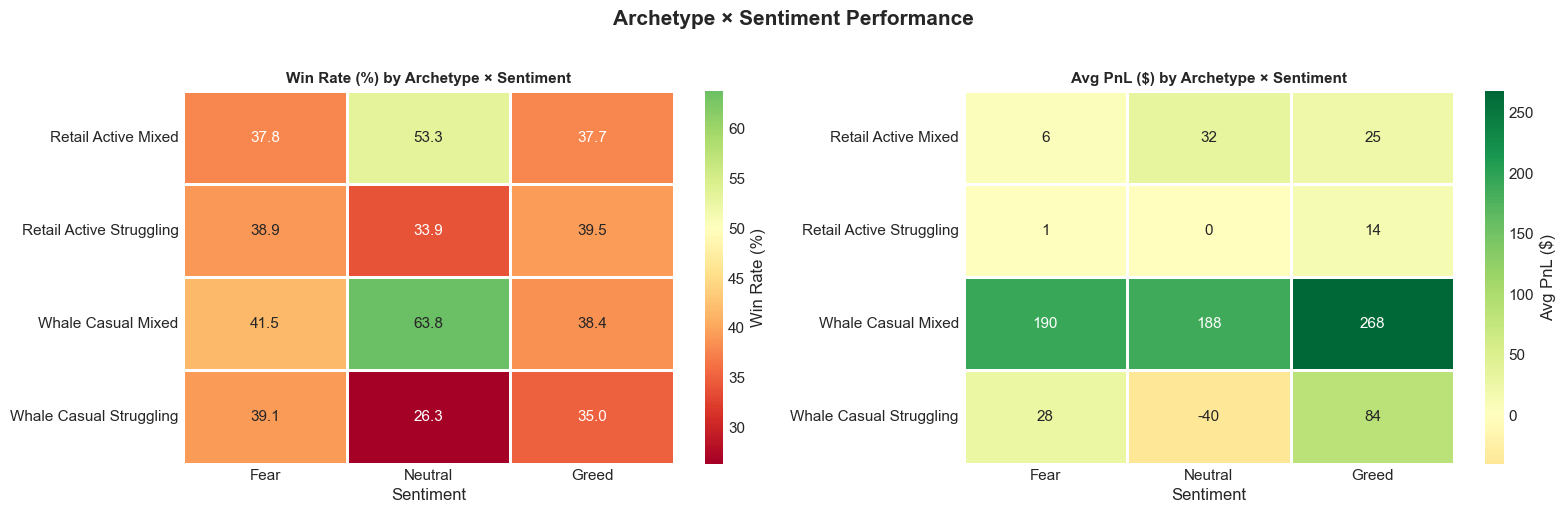

In [257]:
# =============================================================
# D.2.6 — Archetype Performance Under Sentiment
# =============================================================

# Merge archetype labels back to trade-level data
archetype_lookup = cluster_clean[[ACCOUNT_COL, 'cluster', 'archetype']].copy()
trade_archetype = trade_with_sentiment.merge(archetype_lookup, on=ACCOUNT_COL, how='inner')

# Simplified sentiment
trade_archetype['fear_greed'] = trade_archetype['sentiment'].map({
    'Extreme Fear': 'Fear', 'Fear': 'Fear',
    'Neutral': 'Neutral',
    'Greed': 'Greed', 'Extreme Greed': 'Greed'
})

# Cross-tabulation
arch_sent_perf = trade_archetype.groupby(['archetype', 'fear_greed']).agg(
    avg_pnl    = (PNL_COL, 'mean'),
    win_rate   = ('is_win', 'mean'),
    avg_size   = ('notional_usd', 'mean'),
    num_trades = (PNL_COL, 'count'),
).reset_index()
arch_sent_perf['win_rate'] = (arch_sent_perf['win_rate'] * 100).round(2)

print(" Archetype Performance by Market Sentiment:\n")
print(arch_sent_perf.to_string(index=False))

# Heatmap: Win Rate
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title, fmt, cmap in [
    (axes[0], 'win_rate', 'Win Rate (%) by Archetype × Sentiment', '.1f', 'RdYlGn'),
    (axes[1], 'avg_pnl', 'Avg PnL ($) by Archetype × Sentiment', ',.0f', 'RdYlGn'),
]:
    pivot = arch_sent_perf.pivot_table(index='archetype', columns='fear_greed', values=metric)
    col_order = [c for c in ['Fear', 'Neutral', 'Greed'] if c in pivot.columns]
    pivot = pivot[col_order]
    
    center = 50 if metric == 'win_rate' else 0
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, center=center,
                ax=ax, cbar_kws={'label': title.split('by')[0].strip()}, linewidths=1)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('')
    ax.set_xlabel('Sentiment')

plt.suptitle('Archetype × Sentiment Performance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
### Export — Save All Charts & Tables to `outputs/`

In [ ]:
# =============================================================
# EXPORT — Save all charts & tables to outputs/
# =============================================================
import os, matplotlib.pyplot as plt, matplotlib.ticker as mticker

os.makedirs('outputs', exist_ok=True)

# ─── 1. Performance by Sentiment (3-panel bar chart) ───
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_i, (col, ylabel, title, fmt_fn) in enumerate([
    ('avg_daily_pnl',  'Average Daily PnL ($)',     'Avg Daily PnL by Sentiment',
     lambda v: f'${v:,.0f}'),
    ('avg_win_rate',   'Average Win Rate (%)',       'Avg Win Rate by Sentiment',
     lambda v: f'{v:.1f}%'),
    ('avg_volume',     'Average Daily Volume ($)',   'Avg Daily Volume by Sentiment',
     lambda v: f'${v/1e6:.1f}M' if v >= 1e6 else f'${v/1e3:.0f}K'),
]):
    ax = axes[ax_i]
    data = perf_by_sentiment[col]
    colors = [sentiment_colors[s] for s in data.index]
    bars = ax.bar(range(len(data)), data.values, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data.index, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if col == 'avg_daily_pnl':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt_fn(val), ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)

plt.suptitle('Performance Metrics Across Sentiment Regimes', fontsize=16, y=1.02)
plt.tight_layout()
fig.savefig('outputs/01_performance_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.close(fig)
print('✅ Saved outputs/01_performance_by_sentiment.png')

# ─── 2. Behavioral Heatmap ───
fig, ax = plt.subplots(figsize=(10, 5))
cols_to_plot = [c for c in behavior_summary.columns if c != 'trade_count']
normalized = behavior_summary[cols_to_plot].copy()
for c in normalized.columns:
    col_min, col_max = normalized[c].min(), normalized[c].max()
    if col_max != col_min:
        normalized[c] = (normalized[c] - col_min) / (col_max - col_min)
sns.heatmap(normalized, annot=behavior_summary[cols_to_plot].values, fmt='.2f',
            cmap='RdYlGn', ax=ax, linewidths=1, cbar_kws={'label': 'Normalized'})
ax.set_title('Behavioral Metrics by Sentiment Regime', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
fig.savefig('outputs/02_behavioral_heatmap.png', dpi=150, bbox_inches='tight')
plt.close(fig)
print('✅ Saved outputs/02_behavioral_heatmap.png')

# ─── 3. Trader Segmentation Comparison ───
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
seg_configs = [
    ('frequency_seg',    'Frequency Segment',    freq_seg),
    ('consistency_seg',  'Consistency Segment',   cons_seg),
    ('size_seg',         'Position Size Segment', size_seg),
]
for ax, (seg_col, title, df_seg) in zip(axes, seg_configs):
    width = 0.35
    segs = df_seg[seg_col].unique()
    sents = ['Fear', 'Greed']
    x = range(len(segs))
    for i, sent in enumerate(sents):
        vals = [df_seg[(df_seg[seg_col] == s) & (df_seg['fear_greed'] == sent)]['win_rate'].values
                for s in segs]
        vals = [v[0] if len(v) > 0 else 0 for v in vals]
        color = '#e94560' if sent == 'Fear' else '#27ae60'
        ax.bar([xi + i*width for xi in x], vals, width, label=sent, color=color, edgecolor='black', linewidth=0.5)
    ax.set_xticks([xi + width/2 for xi in x])
    ax.set_xticklabels(segs, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Win Rate (%)')
    ax.set_title(title, fontweight='bold')
    ax.legend()
plt.suptitle('Win Rate by Segment × Sentiment', fontsize=15, y=1.02)
plt.tight_layout()
fig.savefig('outputs/03_trader_segments.png', dpi=150, bbox_inches='tight')
plt.close(fig)
print('✅ Saved outputs/03_trader_segments.png')

# ─── 4. Time Series — Rolling PnL vs FGI ───
fig, ax1 = plt.subplots(figsize=(14, 5))
pnl_rolling = merged_df.set_index('date')['total_pnl'].rolling(7).mean()
ax1.plot(pnl_rolling.index, pnl_rolling.values, color='#2196F3', linewidth=1.5, label='7-day Avg PnL')
ax1.set_ylabel('Rolling 7-day Avg PnL ($)', color='#2196F3')
ax1.tick_params(axis='y', labelcolor='#2196F3')
ax2 = ax1.twinx()
ax2.plot(merged_df.set_index('date')['fg_value'], color='#FF9800', alpha=0.6, linewidth=1, label='FGI')
ax2.set_ylabel('Fear & Greed Index', color='#FF9800')
ax2.tick_params(axis='y', labelcolor='#FF9800')
ax2.axhline(50, color='gray', linestyle=':', linewidth=0.8)
ax1.set_title('Rolling PnL vs Fear & Greed Index', fontweight='bold', fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
fig.savefig('outputs/04_time_series.png', dpi=150, bbox_inches='tight')
plt.close(fig)
print('✅ Saved outputs/04_time_series.png')

# ─── 5. Strategy Decision Matrix ───
fig, ax = plt.subplots(figsize=(12, 5))
strategies = [
    ['FGI < 30\n(Ext. Fear)',  'Cut size 50%\nStops at 2%',   'Skip trades\nWait for clarity',    'Reduce 50%\n4H/Daily TF'],
    ['FGI 30–45\n(Fear)',      'Cut size 30%\nTight stops',    'Maintain sizing\nHigh-conviction',  'Reduce 30%\nBe selective'],
    ['FGI 45–55\n(Neutral)',   'Normal sizing',                'Normal sizing',                     'Normal frequency'],
    ['FGI 55–75\n(Greed)',     'Normal sizing\nTrail stops',   'Normal sizing\nTrail stops',        'Normal\nTake profits'],
    ['FGI > 75\n(Ext. Greed)', 'Cut exposure 40%\nTake profit','Cut exposure 25%\nTake profit',     'Cut entries 30%\nNo FOMO'],
]
col_labels = ['Regime', 'Inconsistent\nTraders', 'Consistent\nWinners', 'Frequency\nGuidance']
row_colors = ['#ffcccc','#ffe0cc','#ffffcc','#ccffcc','#ccffe0']
ax.axis('off')
table = ax.table(cellText=strategies, colLabels=col_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#1a1a2e')
    table[0, j].set_text_props(color='white', fontweight='bold')
for i in range(len(strategies)):
    table[i+1, 0].set_facecolor(row_colors[i])
    table[i+1, 0].set_text_props(fontweight='bold')
ax.set_title('Strategy Decision Matrix — Sentiment-Adaptive Trading Rules',
             fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
fig.savefig('outputs/05_strategy_matrix.png', dpi=150, bbox_inches='tight')
plt.close(fig)
print('✅ Saved outputs/05_strategy_matrix.png')

# ─── 6. ML Confusion Matrix ───
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay.from_estimator(best_pipeline, X_test, y_test,
                                              display_labels=le.classes_, ax=ax, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
plt.tight_layout()
fig.savefig('outputs/06_model_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.close(fig)
print('✅ Saved outputs/06_model_confusion_matrix.png')

# ─── 7. Cluster PCA Scatter ───
fig, ax = plt.subplots(figsize=(8, 6))
cluster_colors = ['#e94560', '#0f3460', '#27ae60', '#f39c12', '#8e44ad']
for c in sorted(cluster_clean['cluster'].unique()):
    mask = cluster_clean['cluster'] == c
    label = cluster_clean.loc[mask, 'archetype'].iloc[0]
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=label, alpha=0.6,
               s=30, color=cluster_colors[c % len(cluster_colors)], edgecolors='white', linewidth=0.3)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title('Trader Clusters (PCA Projection)', fontweight='bold')
ax.legend(fontsize=9, loc='best')
plt.tight_layout()
fig.savefig('outputs/07_cluster_pca.png', dpi=150, bbox_inches='tight')
plt.close(fig)
print('✅ Saved outputs/07_cluster_pca.png')

# ─── Tables (CSV) ───
perf_by_sentiment.to_csv('outputs/segment_performance.csv')
print('✅ Saved outputs/segment_performance.csv')

trader_profiles.to_csv('outputs/trader_profiles.csv', index=False)
print('✅ Saved outputs/trader_profiles.csv')

cluster_summary.to_csv('outputs/cluster_summary.csv', index=False)
print('✅ Saved outputs/cluster_summary.csv')

print('\n All outputs saved to outputs/ folder.')